In [12]:
#Set path to parent directory
import sys
sys.path.append("..")
import numpy as np, torch
import scipy.stats as st
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import itertools
from decompTCR.tools._basis_decomposition.run_batch import compute_basis_decomposition, _plot_basis, get_basis
from decompTCR.tools._basis_decomposition.inference  import InferenceMode
from pyro.infer import Predictive, TraceEnum_ELBO
import matplotlib.pyplot as plt
import matplotlib
import scanpy as sc
import seaborn as sns
import pandas as pd
import pickle
import os
from sklearn.preprocessing import MaxAbsScaler, StandardScaler, MinMaxScaler
import datetime
from umap import UMAP

import pyro

from sklearn.neighbors import kneighbors_graph
from sknetwork.clustering import Louvain
from umap import UMAP
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score



from decompTCR.tools._basis_decomposition.inference import get_inference_guide
from decompTCR.tools._basis_decomposition.model_batch import BasisDecomposition, BasisDecomposition_Evaluate
from pyro.infer import Predictive, SVI, Trace_ELBO, TraceTMC_ELBO

from kneed import KneeLocator
import kneed
import statsmodels.api as sm
from matplotlib.colors import LinearSegmentedColormap

from utils import display_cat, clear_val_params, summary, process_data, find_sequence_rows_regex, clustermap


## Load Data and Preprocessing
Data file is expected to be a file that is n x p matrix, where there are n clones across all patients and p features including
- frequency (templates/total templates, per patient and per timepoint)
- templates (# of T cells per timepoint and patient)
- timepoint 
- tag   (Unique identifier for clone, combination of cdr3_amino acid, v_resolved, and j_resolved)
- PatientID
- cdr3_amino_acid (Amino acid sequence of cdr3 region)
- v_resolved
- j_resolved
- ifexpanded  
- allo      (True if alloreactive)
- cell_type (Can either be CD4, CD8 or both)
- GVHD_GRADE_1
- GVHD_GRADE_2
- GVHD_GRADE_3
- Onset (Onset in Days)
- Age_R
- DonorType
- PTCy (True if recieved PTCy)
- Sex
- mapped Whether or not cells are mapped from single cell
- Tissue_Location
- Migration_all 
- leiden_0.5 (Clustering from single cell analysis)
- clone_encoding
- time_encoding

In [21]:
data = pd.read_csv("../input_data/sample_data.csv", low_memory=False) #Insert the correct path to your data file

In [22]:
#Load Data
meta_data = ["ifexpanded", "allo", "cell_type", "GVHD_GRADE_1", "GVHD_GRADE_2", "GVHD_GRADE_3", "Onset", "Age_R", "DonorType", "PTCy", "Sex", "HLA_mis", "Conditioning", "mapped", "Tissue_Location", "Migration_all", "leiden_0.5"]

clone_pattern_dense_filtered, data, filter_idx = process_data(data, meta_data, last_timepoint = 180, n_filter = 2)

In [23]:
#Change Unclassified/Severe Patient To Severe
data.loc[data["GVHD_GRADE_1"] == "Unclassified/Severe", "GVHD_GRADE_1"] = "Severe"
data.loc[data["GVHD_GRADE_1"] == "Unclassified/Severe", "GVHD_GRADE_2"] = "Severe"

In [24]:
#Filter data for only alloreactive clones
data_down = data.drop(["frequency", "time_encoding", "timepoint"], axis = 1)
data_down = data_down.drop_duplicates(subset=["clone_encoding", "tag"])
data_down = data_down.sort_values(by = "clone_encoding")
data_down = data_down.reset_index(drop = True)

data_filt = data_down[filter_idx.numpy()]

data_filt_na = data_filt[data_filt["allo"] == False].reset_index(drop = True).reset_index()
data_filt_a = data_filt[data_filt["allo"] == True].reset_index(drop = True).reset_index()


clone_patterns_na = clone_pattern_dense_filtered[(data_filt["allo"]==False).values]
clone_patterns_a = clone_pattern_dense_filtered[(data_filt["allo"]==True).values]

data_filt_a["GVHD_GRADE_1"] = pd.Categorical(data_filt_a["GVHD_GRADE_1"], categories = ["No", "Mild", "Severe"])

In [25]:
#Add padding to the clone patterns for fitting the model. You can increase or decrease the padding based on your data.
times_padded = np.linspace(-1,1, clone_pattern_dense_filtered.shape[1]) #Create a vector with the proper length of time. Time is normalized in this case from -1,1 and length of 181
nan_padding = torch.full((clone_pattern_dense_filtered.shape[0],10), fill_value = torch.nan )
clone_patterns_padded = torch.cat((clone_pattern_dense_filtered, nan_padding), dim=1)

nan_padding_allo = torch.full((clone_patterns_a.shape[0],10), fill_value = torch.nan )
clone_patterns_padded_allo = torch.cat((clone_patterns_a, nan_padding_allo), dim=1)

nan_padding_nonallo = torch.full((clone_patterns_na.shape[0],10), fill_value = torch.nan )
clone_patterns_padded_nonallo = torch.cat((clone_patterns_na, nan_padding_nonallo), dim=1)

In [26]:
idxs = np.argsort(times_padded) #Ensure that the columns are sorted by time
times_padded = times_padded[idxs]
clone_patterns_padded = clone_patterns_padded[:,idxs]
clone_patterns_padded_allo = clone_patterns_padded_allo[:,idxs]
clone_patterns_padded_nonallo = clone_patterns_padded_nonallo[:,idxs]

In [27]:
#Train Test Split for nonalloreactive clones
train_na_idx, val_na_idx = train_test_split(np.arange(len(clone_patterns_padded_nonallo)), test_size = .2)
clone_patterns_padded_nonallo_train = clone_patterns_padded_nonallo[train_na_idx, :]
clone_patterns_padded_nonallo_val = clone_patterns_padded_nonallo[val_na_idx, :]


In [20]:
#Train Test Split for alloreactive clones

train_a_idx, val_a_idx = train_test_split(np.arange(clone_patterns_padded_allo.shape[0]), test_size = 0.1)
clone_patterns_padded_allo_train = clone_patterns_padded_allo[train_a_idx,:]
clone_patterns_padded_allo_val = clone_patterns_padded_allo[val_a_idx,:]

## Train and Fit the Model


In [112]:
#Set Parameters
hyperparameters= {
"n_basis":12,
"n_iter":3000,
"batch_size": None,
"lr" : 1e-2,
"beta_prior" :.95,
"weight_decay" : 1e-7,
"inverse_length_scale" : 5
}

### Uncomment Below to Run Basis

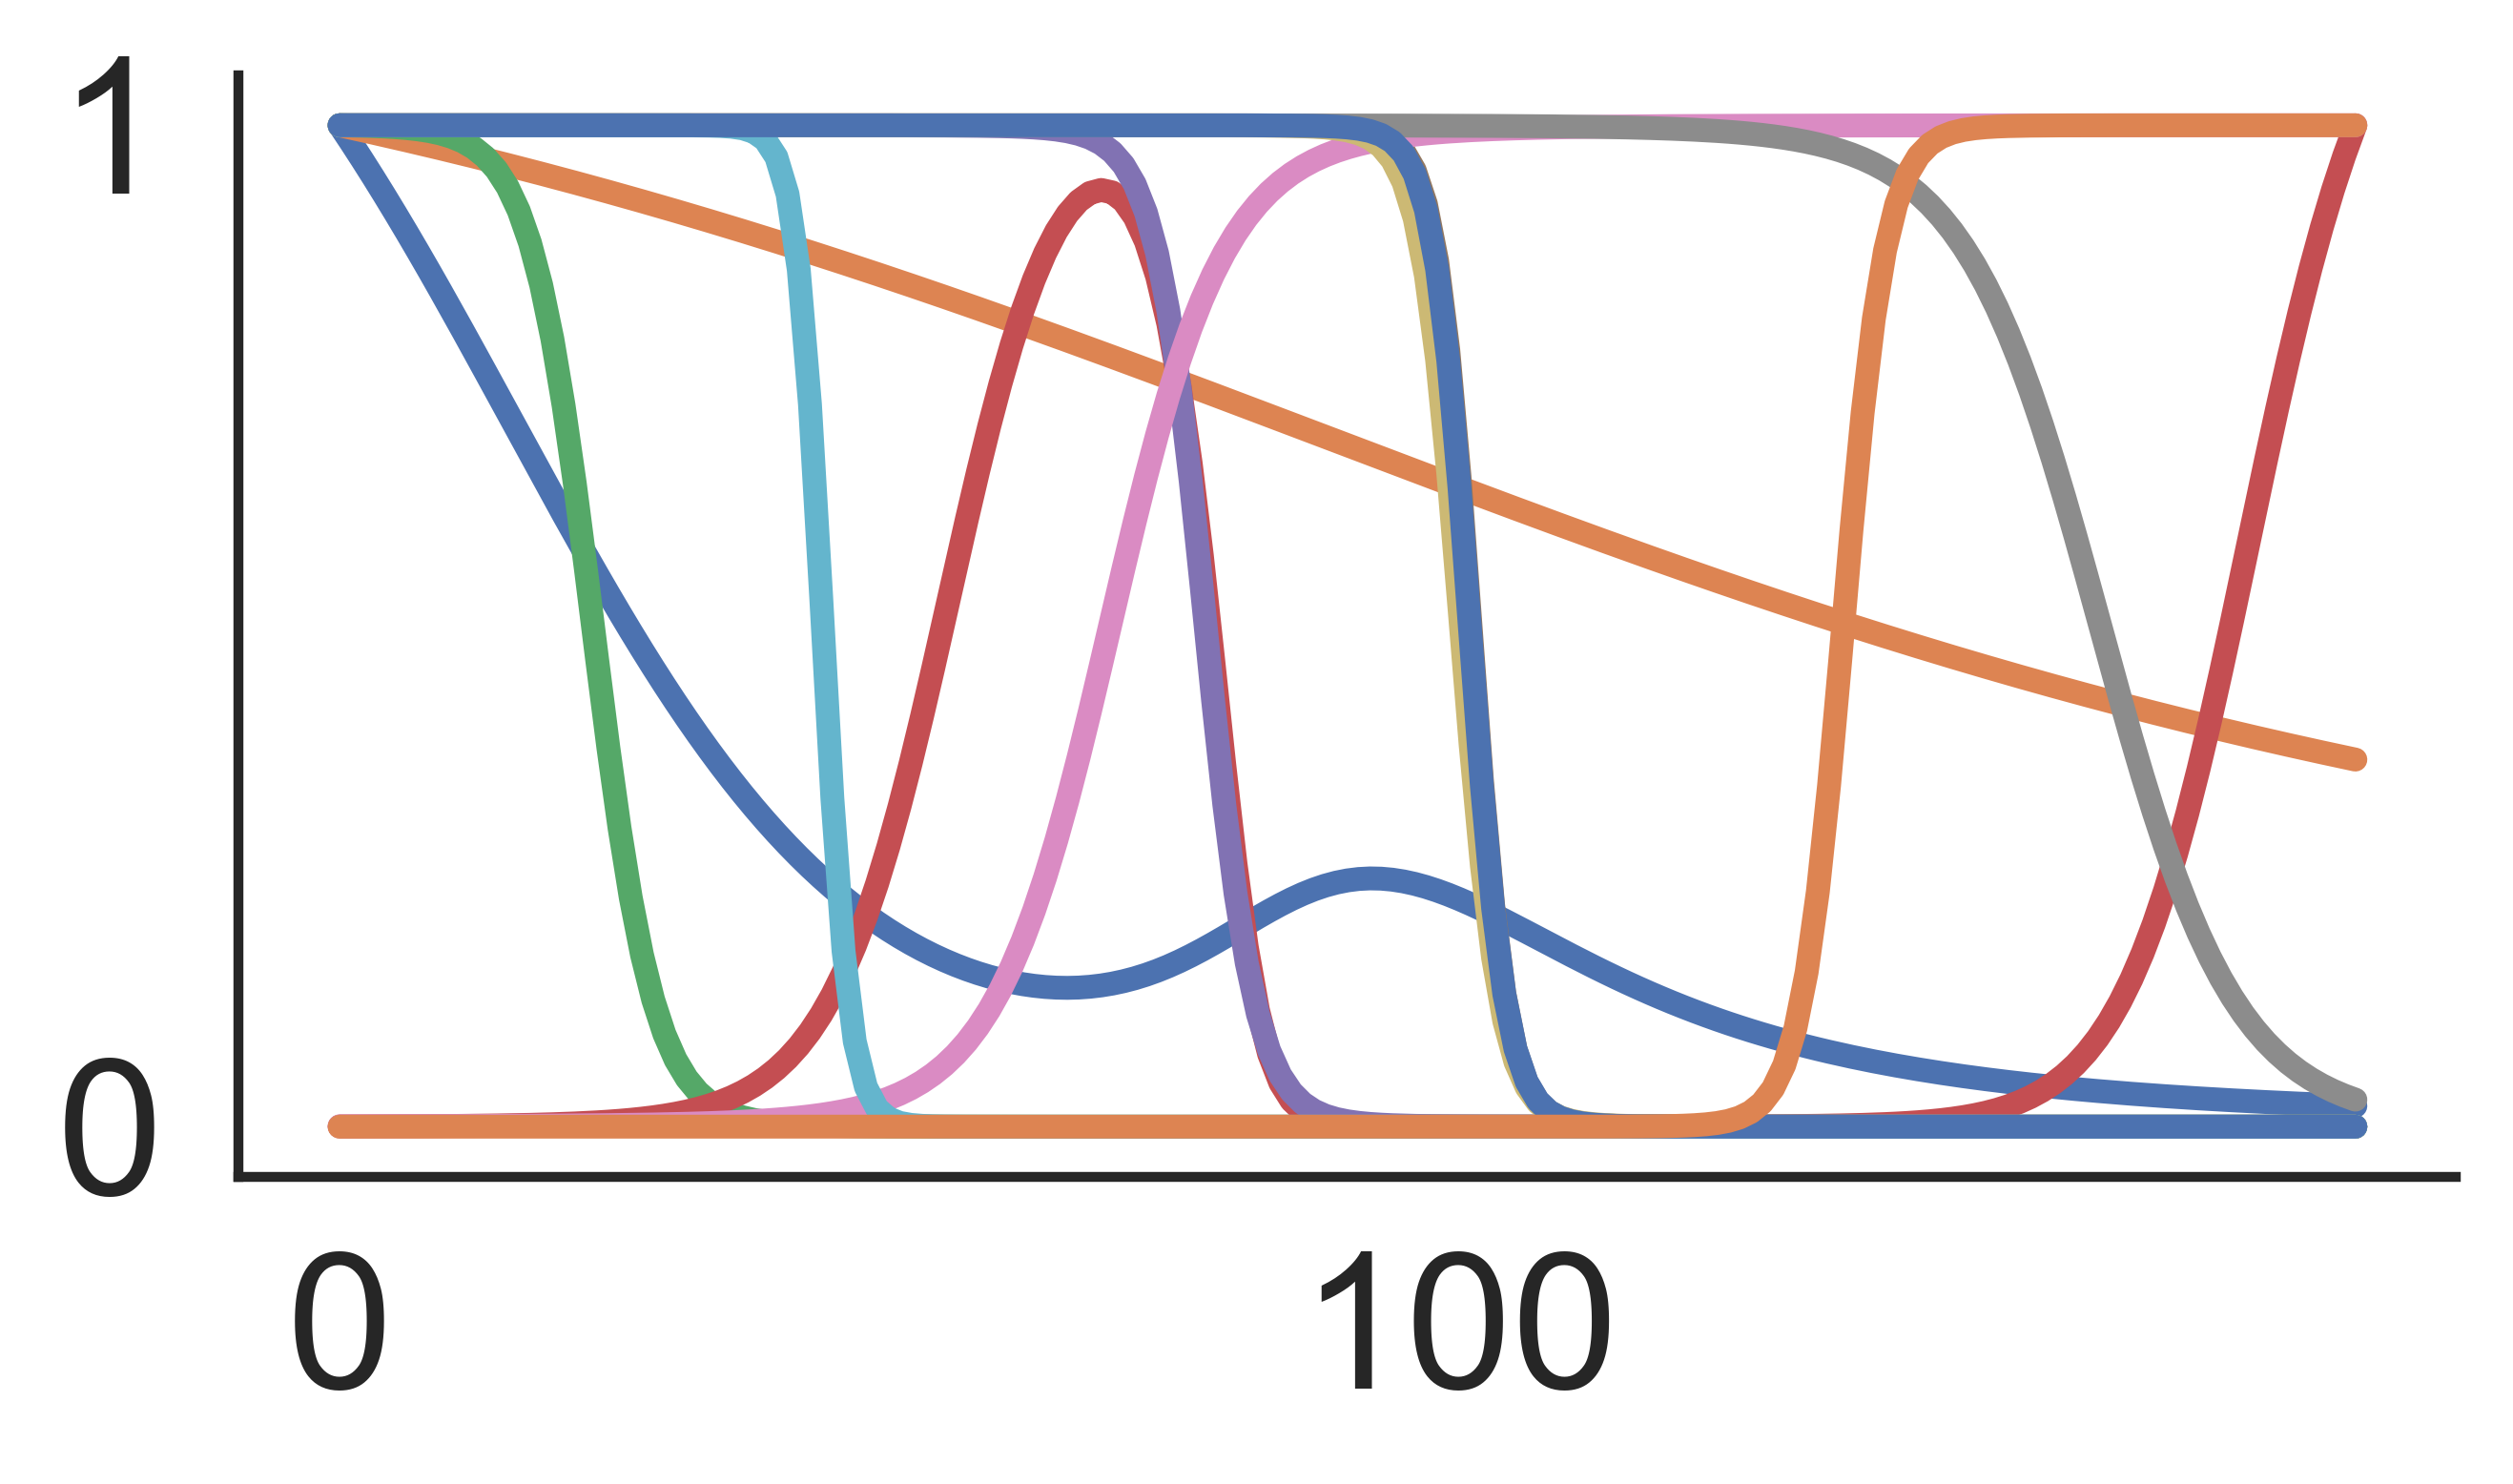

Loss: 6475.9 - Relative Error: 1.17, - Val_loss: 0.68: 100%|██████████| 3000/3000 [03:32<00:00, 14.13it/s]


In [113]:
trajectory_model_a, guide_a, times_a, samples_a, clone_scales_a, losses_a, rel_loss_a, val_loss_a = compute_basis_decomposition(
clone_patterns_padded_allo_train.numpy(),#clone_patterns_masked,#clone_patterns_padded,
InferenceMode.POINT_ESTIMATE, #GAUSSIAN_BETA_ONLY
n_basis= hyperparameters["n_basis"],
n_iter= hyperparameters["n_iter"],
batch_size= hyperparameters["batch_size"],
lr= hyperparameters["lr"],
beta_prior= hyperparameters["beta_prior"],
weight_decay =  hyperparameters["weight_decay"],
inverse_length_scale =  hyperparameters["inverse_length_scale"],
seed=3,
normalized_mode=True,
times = times_padded,
plot_every_k_epochs=100,
clone_patterns_val= clone_patterns_padded_allo_val.numpy()
) 

basis_a = get_basis(trajectory_model_a, guide_a, clone_patterns_padded_allo_train.numpy(), times_padded)


In [114]:
def save_run_data(directory, filename, X, times, trajectory_model, guide, samples, clone_scales, rel_loss, val_loss, train_idx, val_idx, basis, specific_datetime_string,  hyperparameters):
    
    os.makedirs(directory, exist_ok=True) # Ensure directory exists
    checkpoint = {
        'trajectory_model_a_obj_params': trajectory_model.__dict__,
        'guide_state_dict': guide.state_dict(),
        'times': times,
        'samples': samples,
        'clone_scales': clone_scales,
        'rel_loss': rel_loss,
        'val_loss': val_loss,
        'train_idx': train_idx,
        'val_idx': val_idx,
        'basis': basis,
        '_last_basis': trajectory_model._last_basis, # Assuming _last_basis is a relevant attribute
        # Add any other metadata you want to save, e.g.:
        'training_epochs':  hyperparameters["n_iter"], 
        'learning_rate':  hyperparameters["lr"], 
        'n_basis':  hyperparameters["n_basis"], 
        'beta_prior':  hyperparameters["beta_prior"], 
        'weight_decay':  hyperparameters["weight_decay"], 
        'inverse_length_scale':  hyperparameters["inverse_length_scale"], 
        'run_timestamp': specific_datetime_string # Store the used timestamp
    }

    # Save the entire checkpoint dictionary to a single .pth file
    # Use the specific_datetime_string in the filename
    save_path = os.path.join(directory, f"{specific_datetime_string}_{filename}_run_checkpoint.pth")
    torch.save(checkpoint, save_path)

    print(f"All data saved to: {save_path}")

In [115]:
# If you want to generate it from a specific date:
specific_date = datetime.datetime.now() # If you want to choose the date and time datetime(2024, 4, 29, 10, 34, 1) # Year, Month, Day, Hour, Minute, Second
specific_datetime_string = specific_date.strftime("_%Y_%m_%d_%H_%M_%S")

basis_a = get_basis(trajectory_model_a, guide_a, clone_patterns_padded_allo_train.numpy(), times_a)
save_run_data("../input_data/basis_decomp_saved_runs/", "alloreactive", clone_patterns_padded_allo_train, times_padded, trajectory_model_a, guide_a, samples_a, clone_scales_a, rel_loss_a, val_loss_a, train_a_idx, val_a_idx, basis_a, specific_datetime_string,  hyperparameters)

All data saved to: ../input_data/basis_decomp_saved_runs/_2025_10_01_21_27_25_alloreactive_run_checkpoint.pth


### To Load fitted model uncomment below

In [116]:

# load_path = "../input_data/your_saved_file.pth" #Insert the correct path to your saved file

# # Load the entire checkpoint dictionary
# loaded_checkpoint = torch.load(load_path, weights_only=False)

# print(f"Loading data from: {load_path}")

# # # Re-instantiate models and load their state_dicts
# trajectory_model_a = BasisDecomposition(loaded_checkpoint['trajectory_model_a_obj_params']["K"],n_clones = loaded_checkpoint['trajectory_model_a_obj_params']["n_clones"], batch_size=loaded_checkpoint['trajectory_model_a_obj_params']["batch_size"]) # Instantiate your actual model class


# trajectory_model_a._last_basis = loaded_checkpoint['_last_basis'] # Assuming _last_basis is a relevant attribute



# # Extract all other data
# # trajectory_model_a = loaded_checkpoint['trajectory_model_a_obj_params']
# times_a = loaded_checkpoint['times_a']
# samples_a = loaded_checkpoint['samples_a']
# clone_scales_a = loaded_checkpoint['clone_scales_a']
# losses_a = loaded_checkpoint['losses_a']
# rel_loss_a = loaded_checkpoint['rel_loss_a']
# val_loss_a = loaded_checkpoint['val_loss_a']
# train_a_idx = loaded_checkpoint['train_a_idx']
# val_a_idx = loaded_checkpoint['val_a_idx']
# basis_a = loaded_checkpoint['basis_a']

# # Your original code after loading (assuming clone_patterns_padded_allo is available)
# clone_patterns_padded_allo_train = clone_patterns_padded_allo[train_a_idx,:]
# clone_patterns_padded_allo_val = clone_patterns_padded_allo[val_a_idx,:]

## Validating Model Fit and Post-Processing

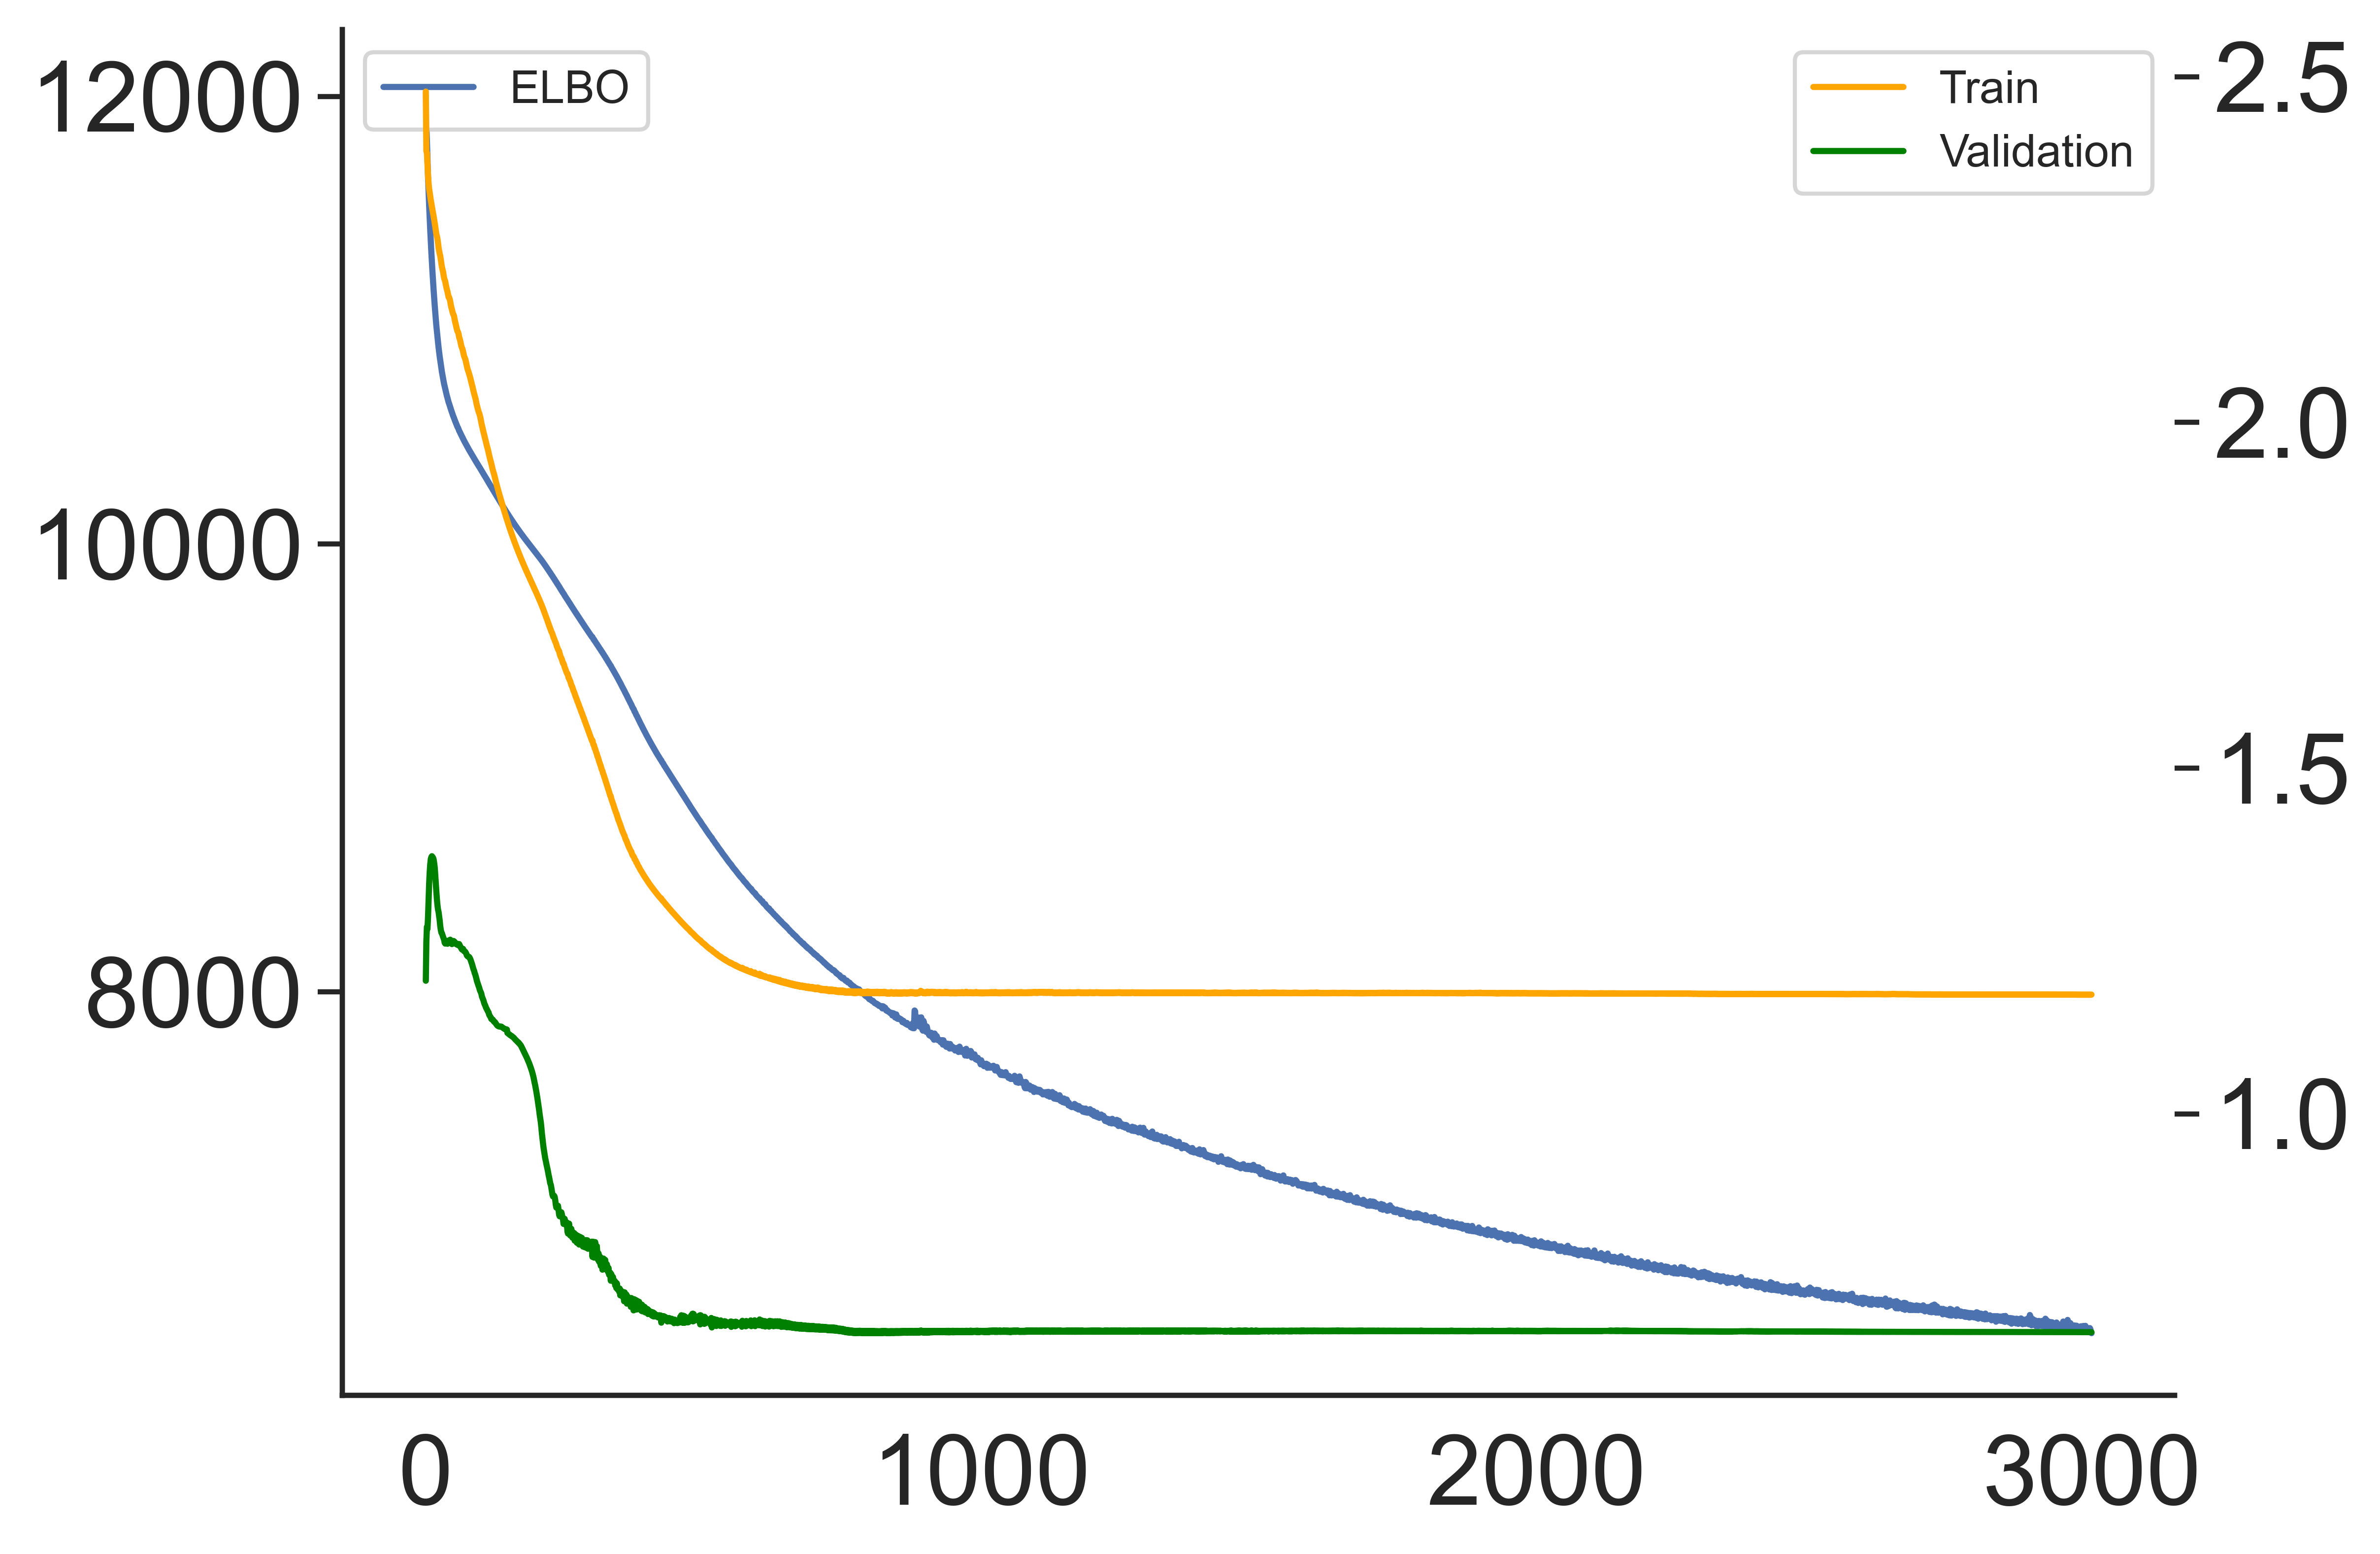

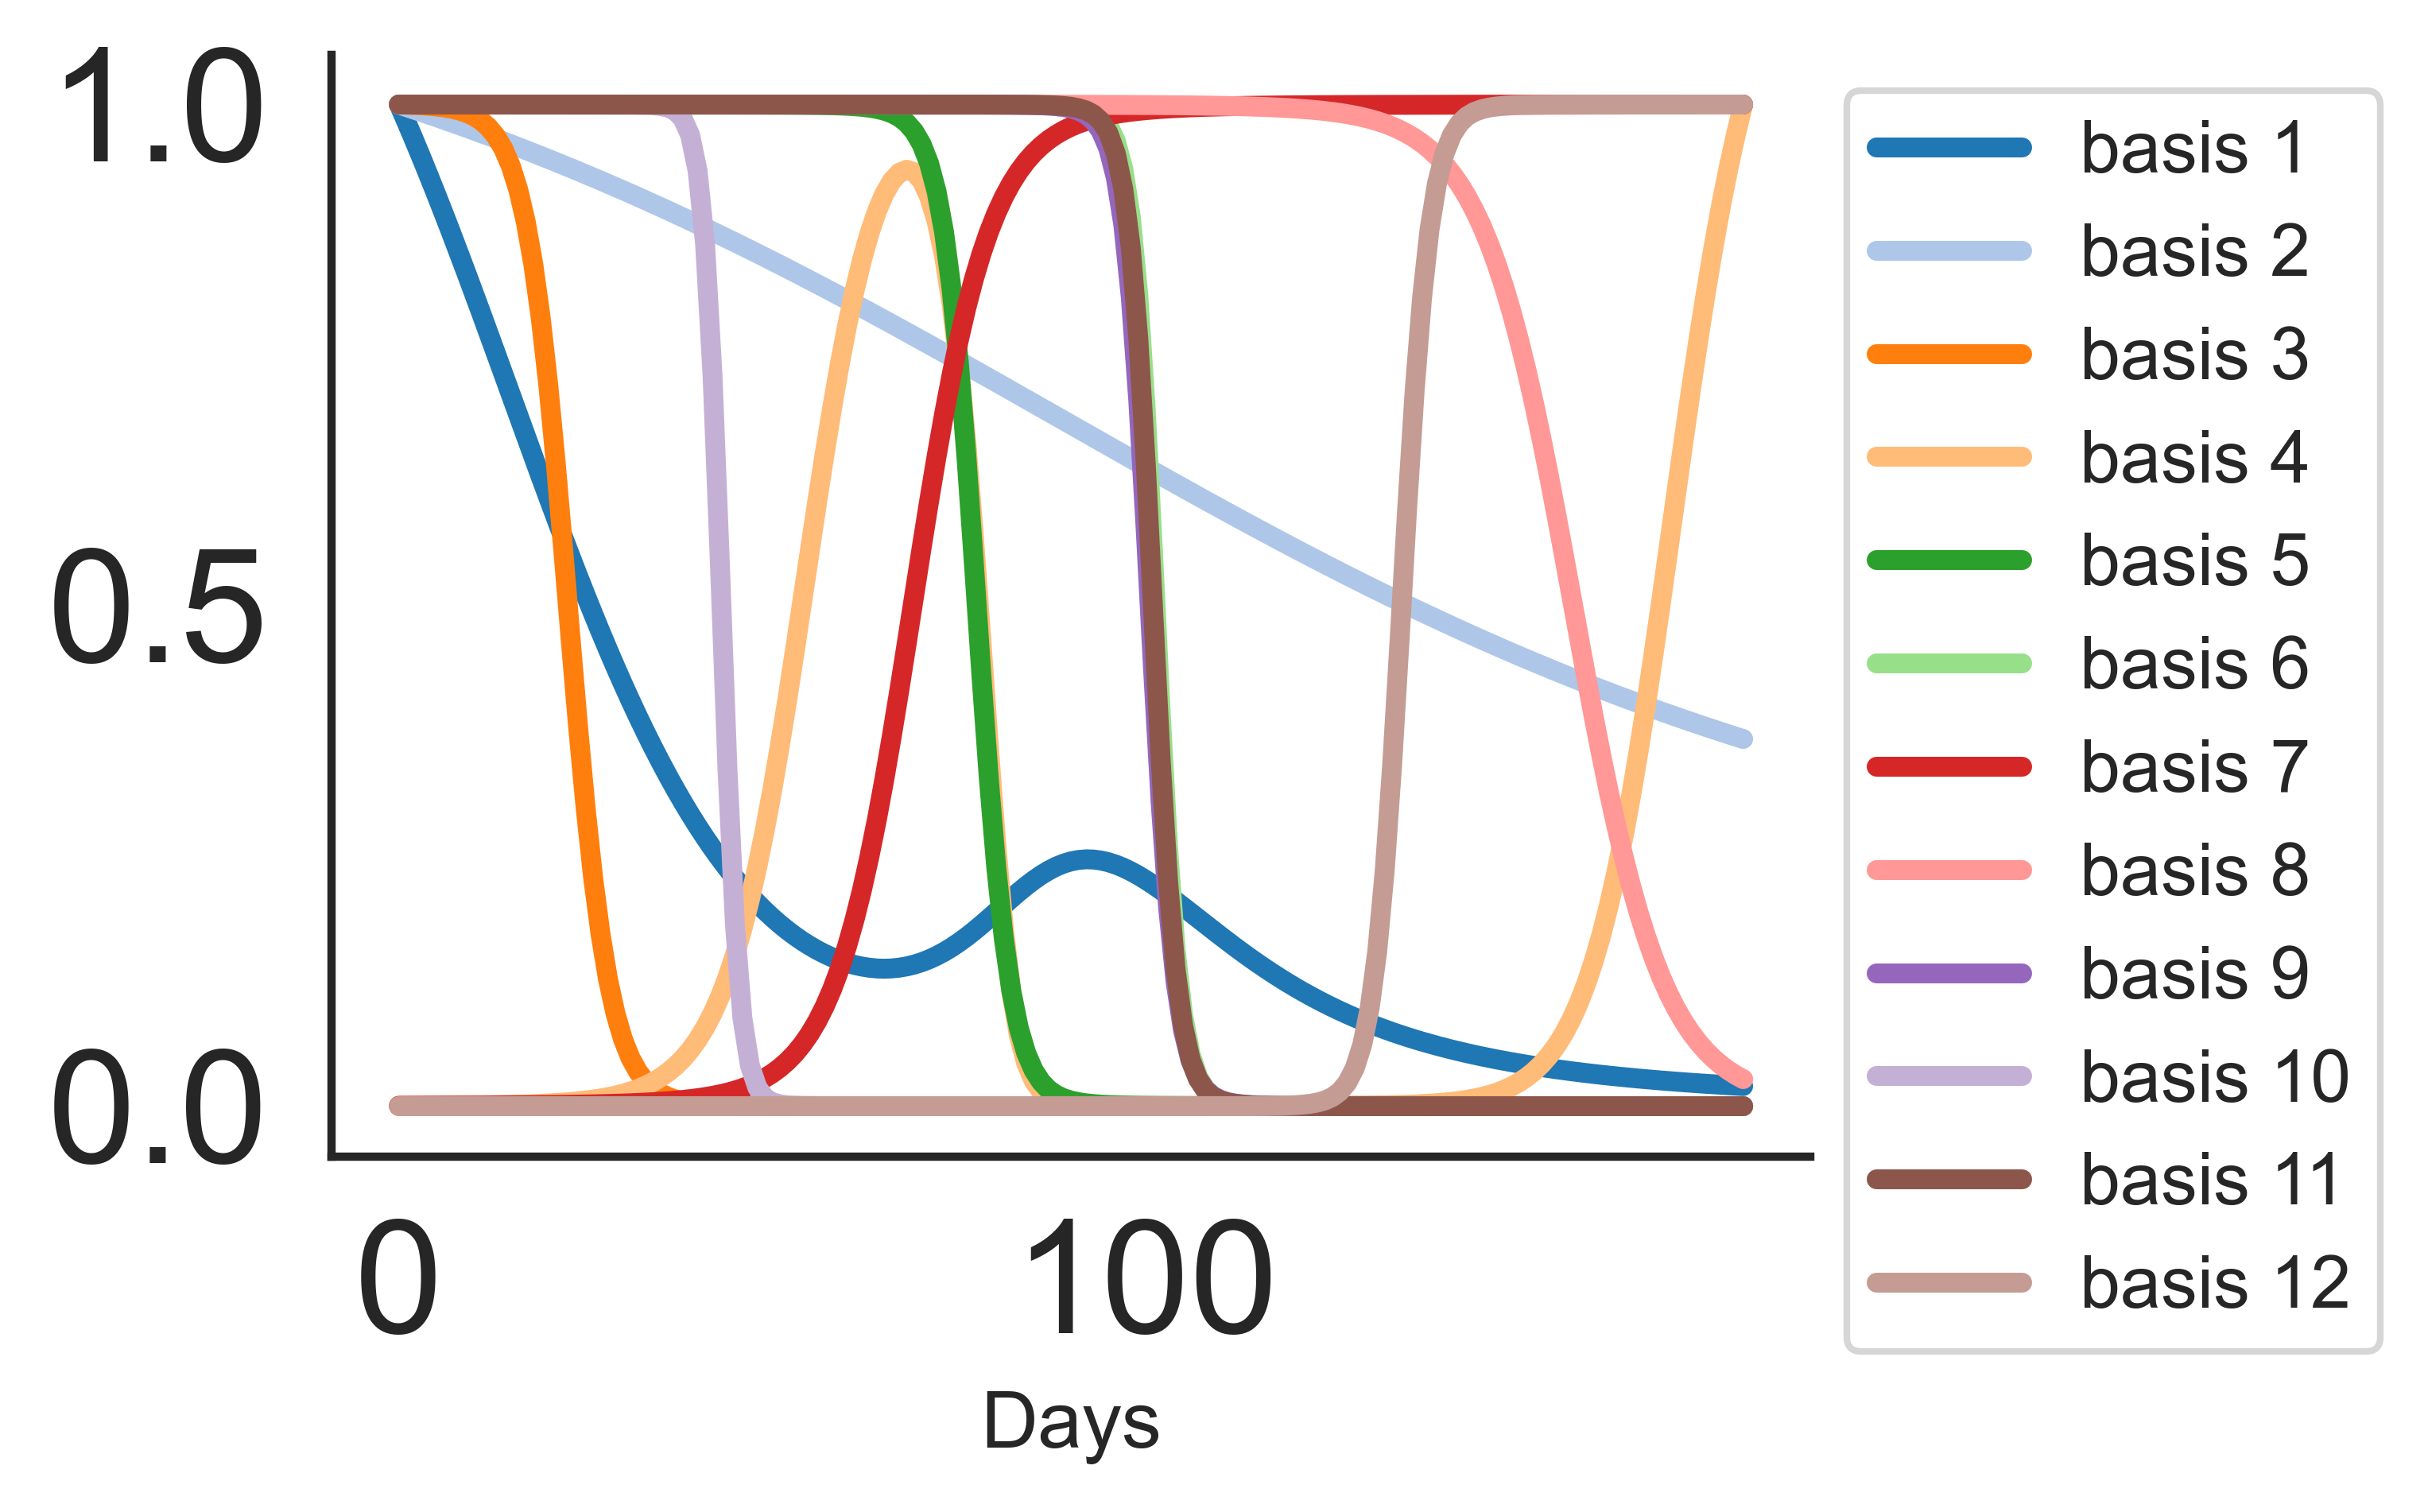

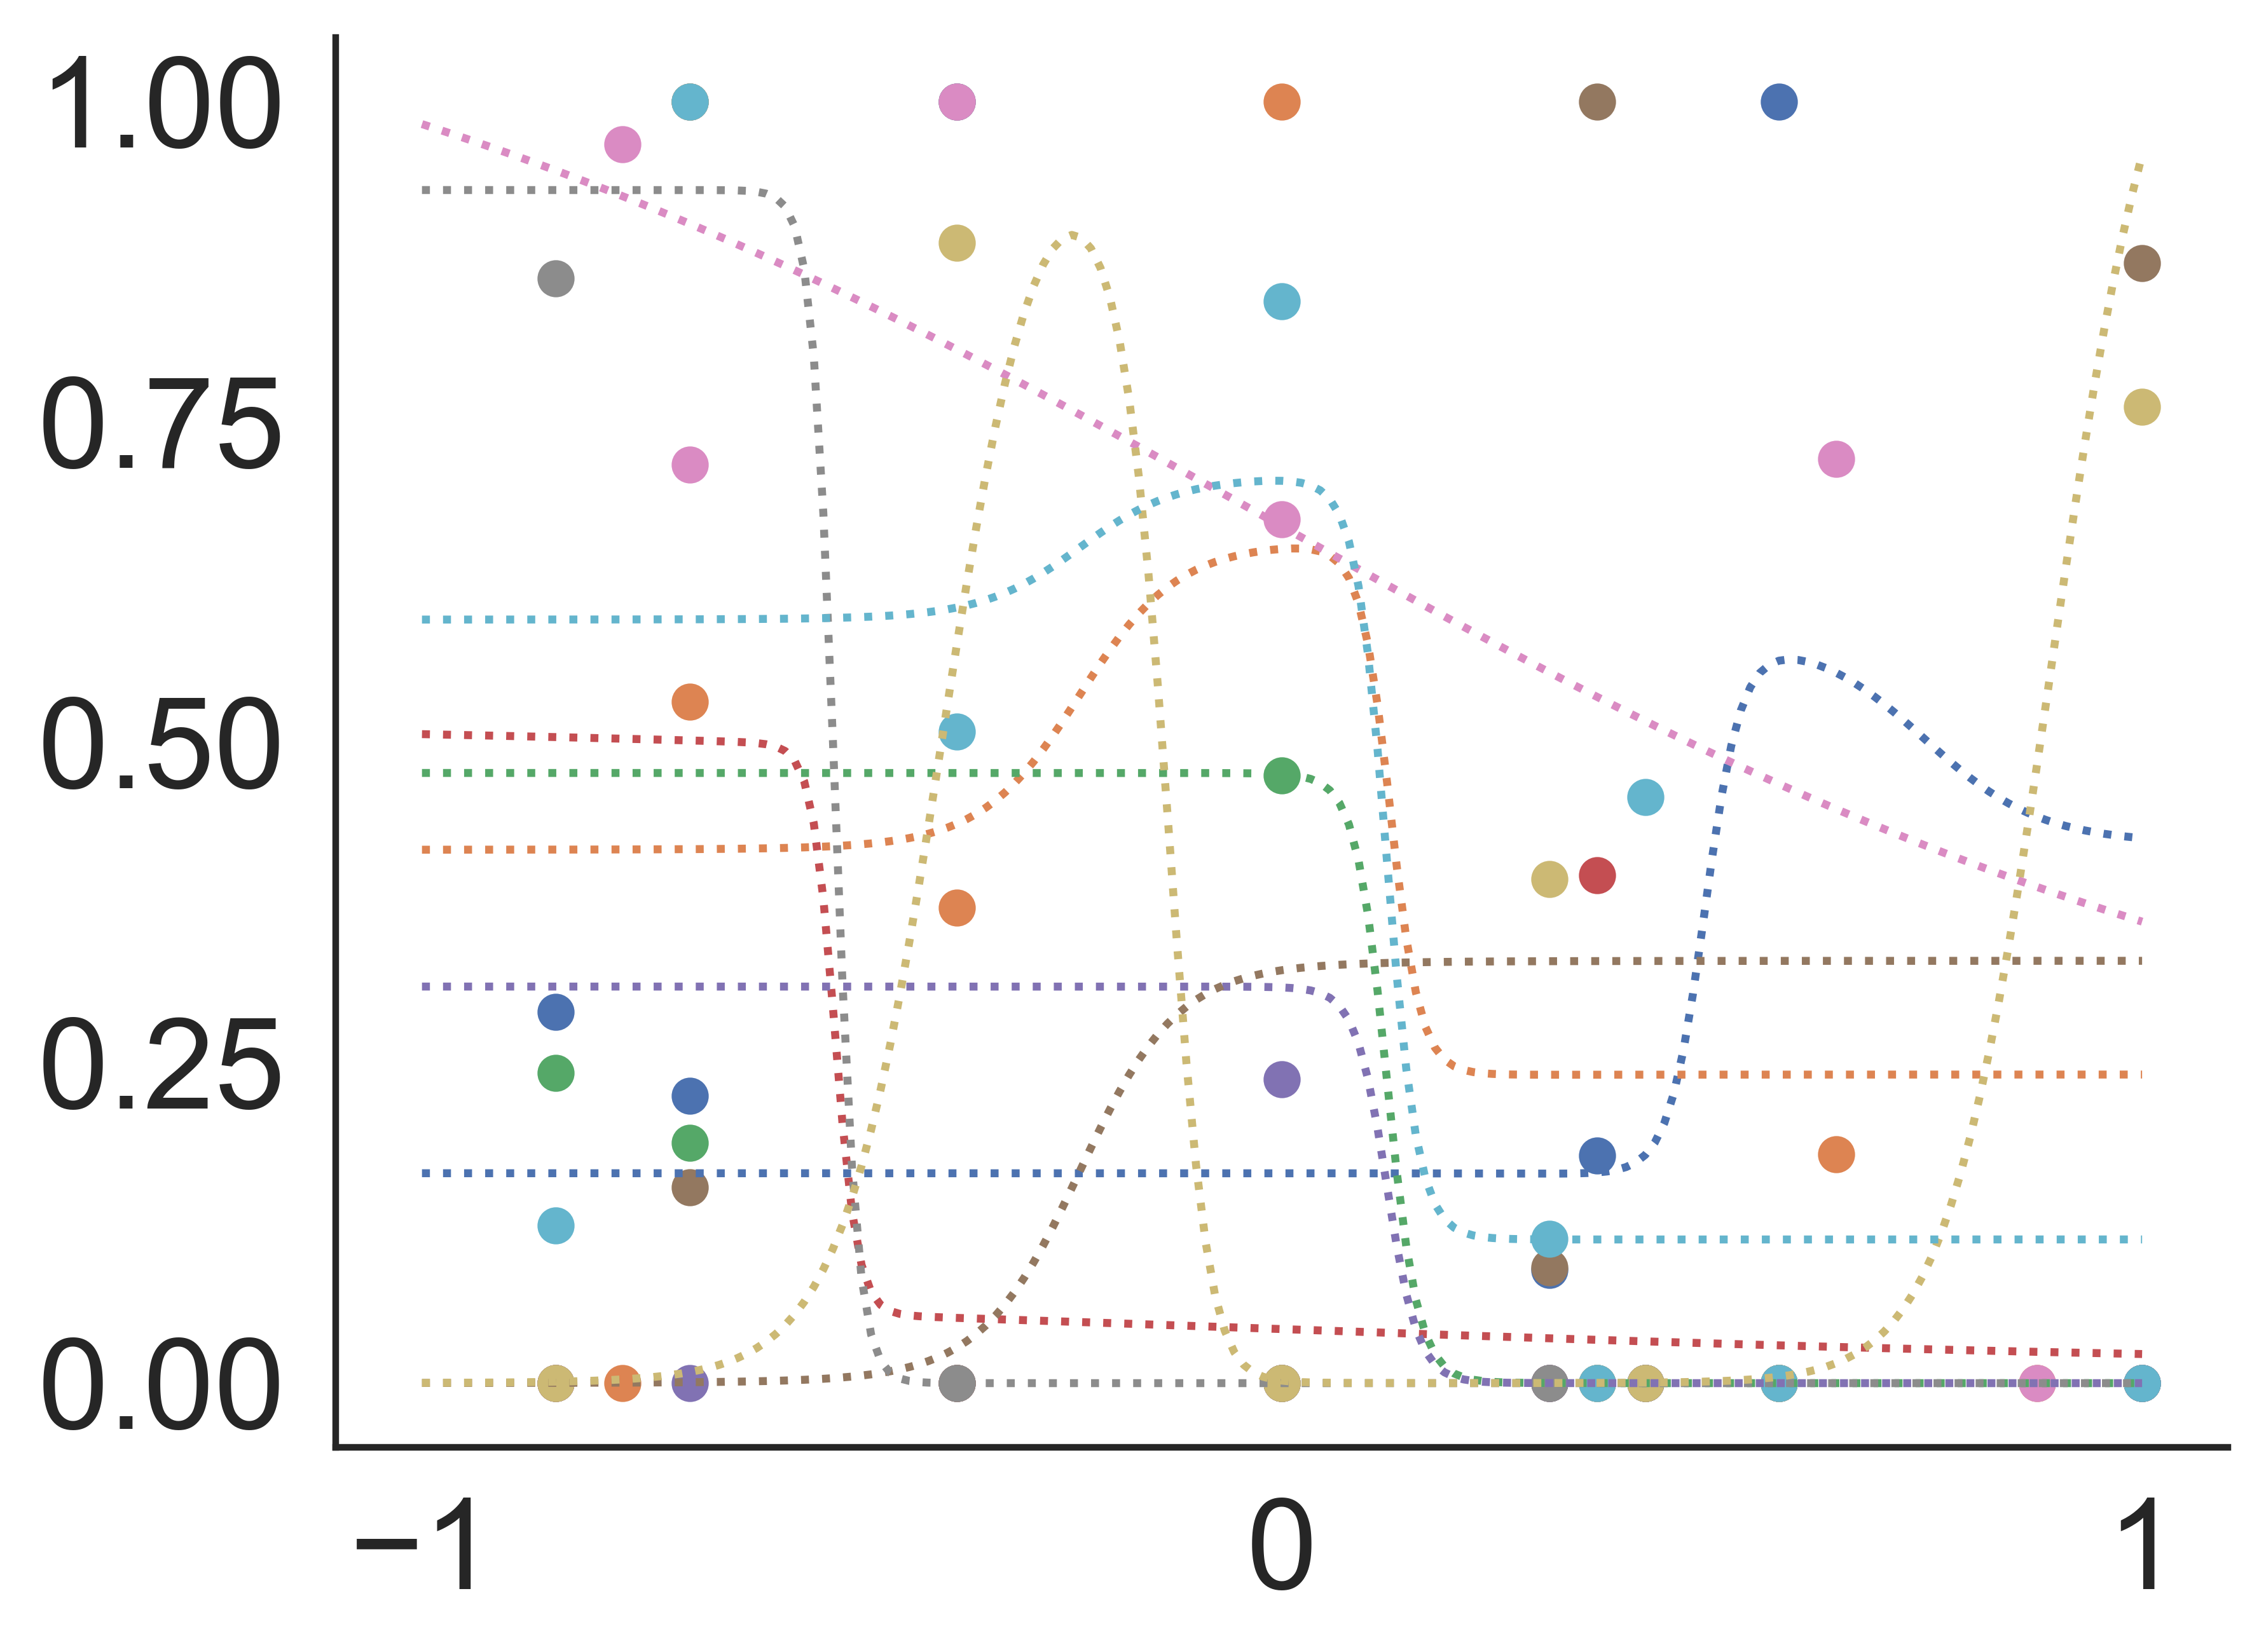

In [117]:
fig, ax = plt.subplots(1,1, figsize = (8,6))
ax.plot(losses_a)
ax2 = ax.twinx()
ax2.plot(rel_loss_a, color = "orange")
ax2.plot(val_loss_a, color = "green")
ax.legend(["ELBO"], loc = "upper left")
ax2.legend(["Train", "Validation"])


colors = sns.color_palette("tab20", 20)


#Display the training and validation curve alongside ELBO. Also plot Basis and some example reconstruction
fig, ax = plt.subplots(1,1, figsize=(4,3), dpi = 600)
plt.rcParams.update({'font.size': 8})
ax = _plot_basis(basis_a, colors)
plt.xlabel("Days")
plt.legend(bbox_to_anchor=(1,1),loc = "upper left")
plt.show()


reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

m = 10
palette = sns.color_palette(n_colors=m)
for i in range(m):
    idx = np.random.randint(0,len(clone_patterns_padded_allo_train))
    plt.scatter(times_padded, clone_patterns_padded_allo_train[idx,:].detach().numpy(), color = palette[i])
    plt.plot(times_padded, reconstruction.numpy()[idx,:], ls = ':', color = palette[i])
plt.show()

To evaluate the model fit we freeze the patterns that we have learned and learn the weights for our validation data.

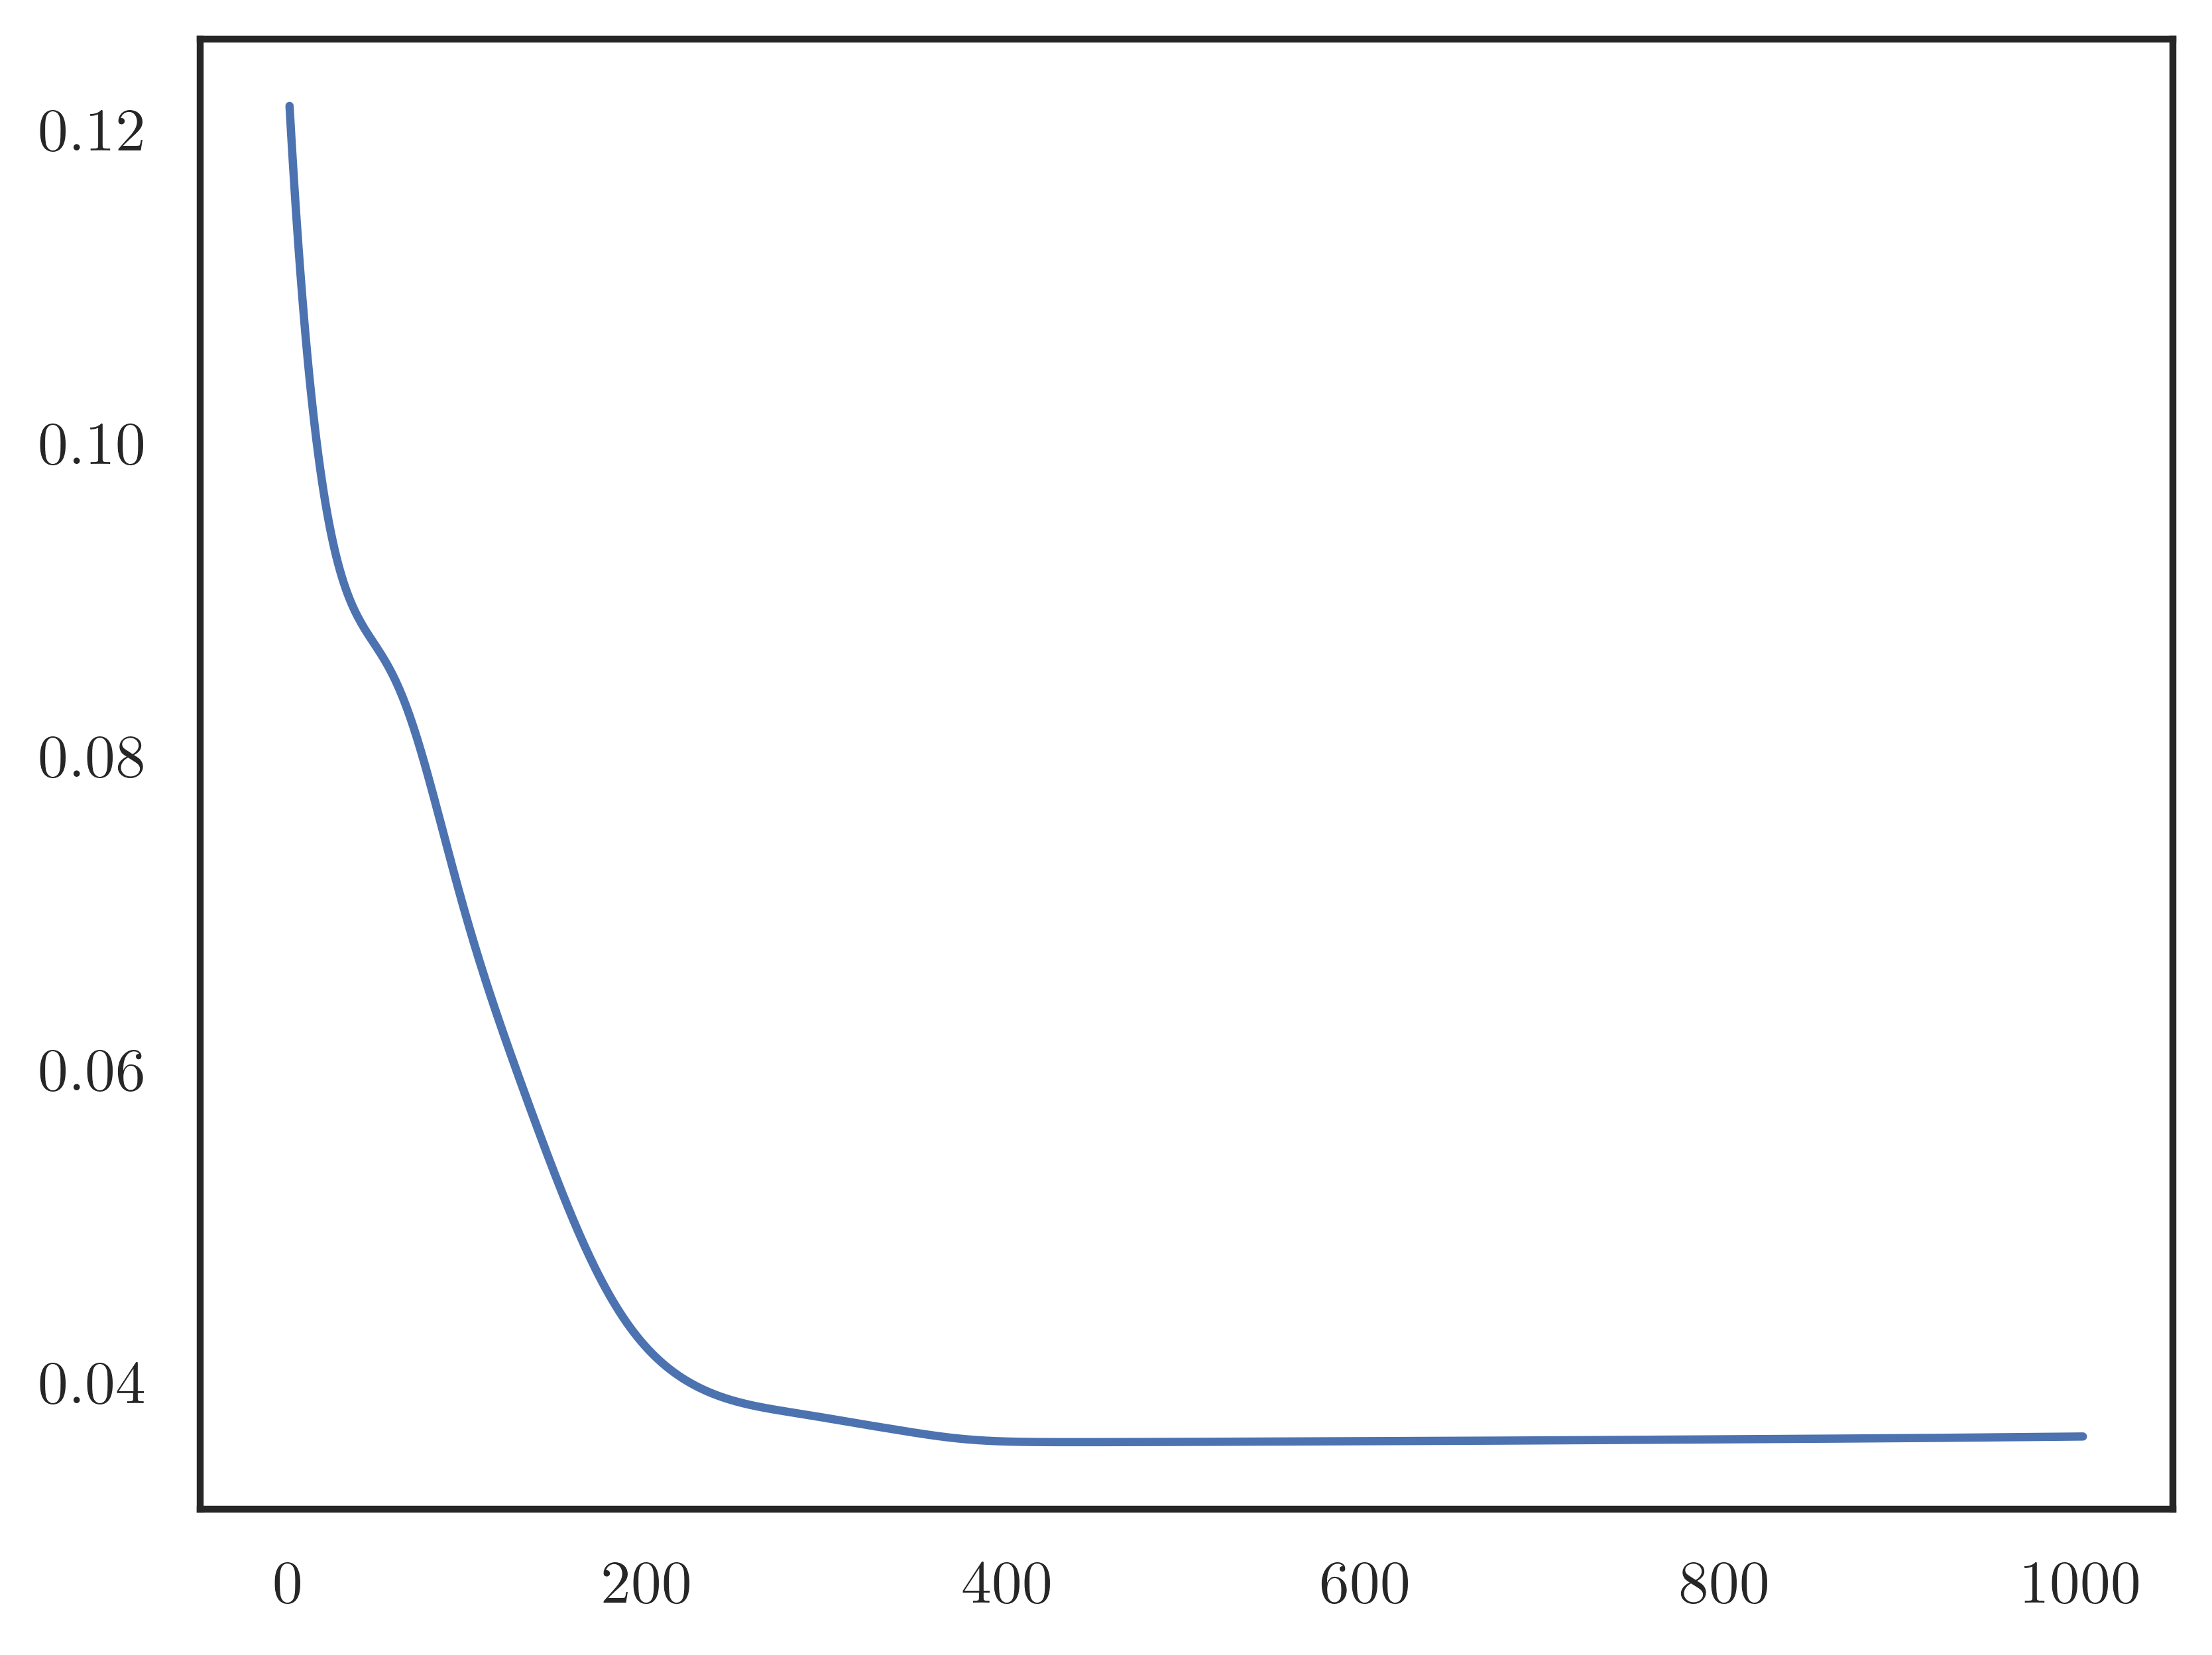

In [130]:
clear_val_params()
#Fit Validation Samples

adam = pyro.optim.ClippedAdam({"lr": .01})#Adam({"lr": lr})
elbo = Trace_ELBO()
    
model_val = BasisDecomposition_Evaluate(
            trajectory_model_a._last_basis.detach(),#torch.Tensor(np.array(my_basis).T),
            n_clones = clone_patterns_padded_allo_val.shape[0],
            beta_prior=hyperparameters["beta_prior"],
            normalized_mode = True
            
        )
guide_val = get_inference_guide(model_val, InferenceMode.POINT_ESTIMATE)
svi_val = SVI(model_val, guide_val, adam, loss=elbo)
val_loss = []
loss_val = 0
for _ in range(1000):
    loss_val = svi_val.step(torch.FloatTensor(times_padded), torch.FloatTensor(clone_patterns_padded_allo_val.numpy()))
    reconstruction_val = ((model_val._last_patterns - clone_patterns_padded_allo_val) ** 2).nanmean().item()
    val_loss.append(reconstruction_val)


plt.plot(val_loss)


samples_val = []
predictive = Predictive(
        model_val, guide=guide_val, num_samples=10, return_sites=("beta_val","_RETURN",  "obs_val")
    )
samples_val = predictive(times_a, clone_patterns_padded_allo_val)

clone_scales_val = model_val.gene_scales 
samples_val = summary(samples_val)


Now that we know that the validation samples are fitted with the given fixed basis functions we can display their reconstruction.

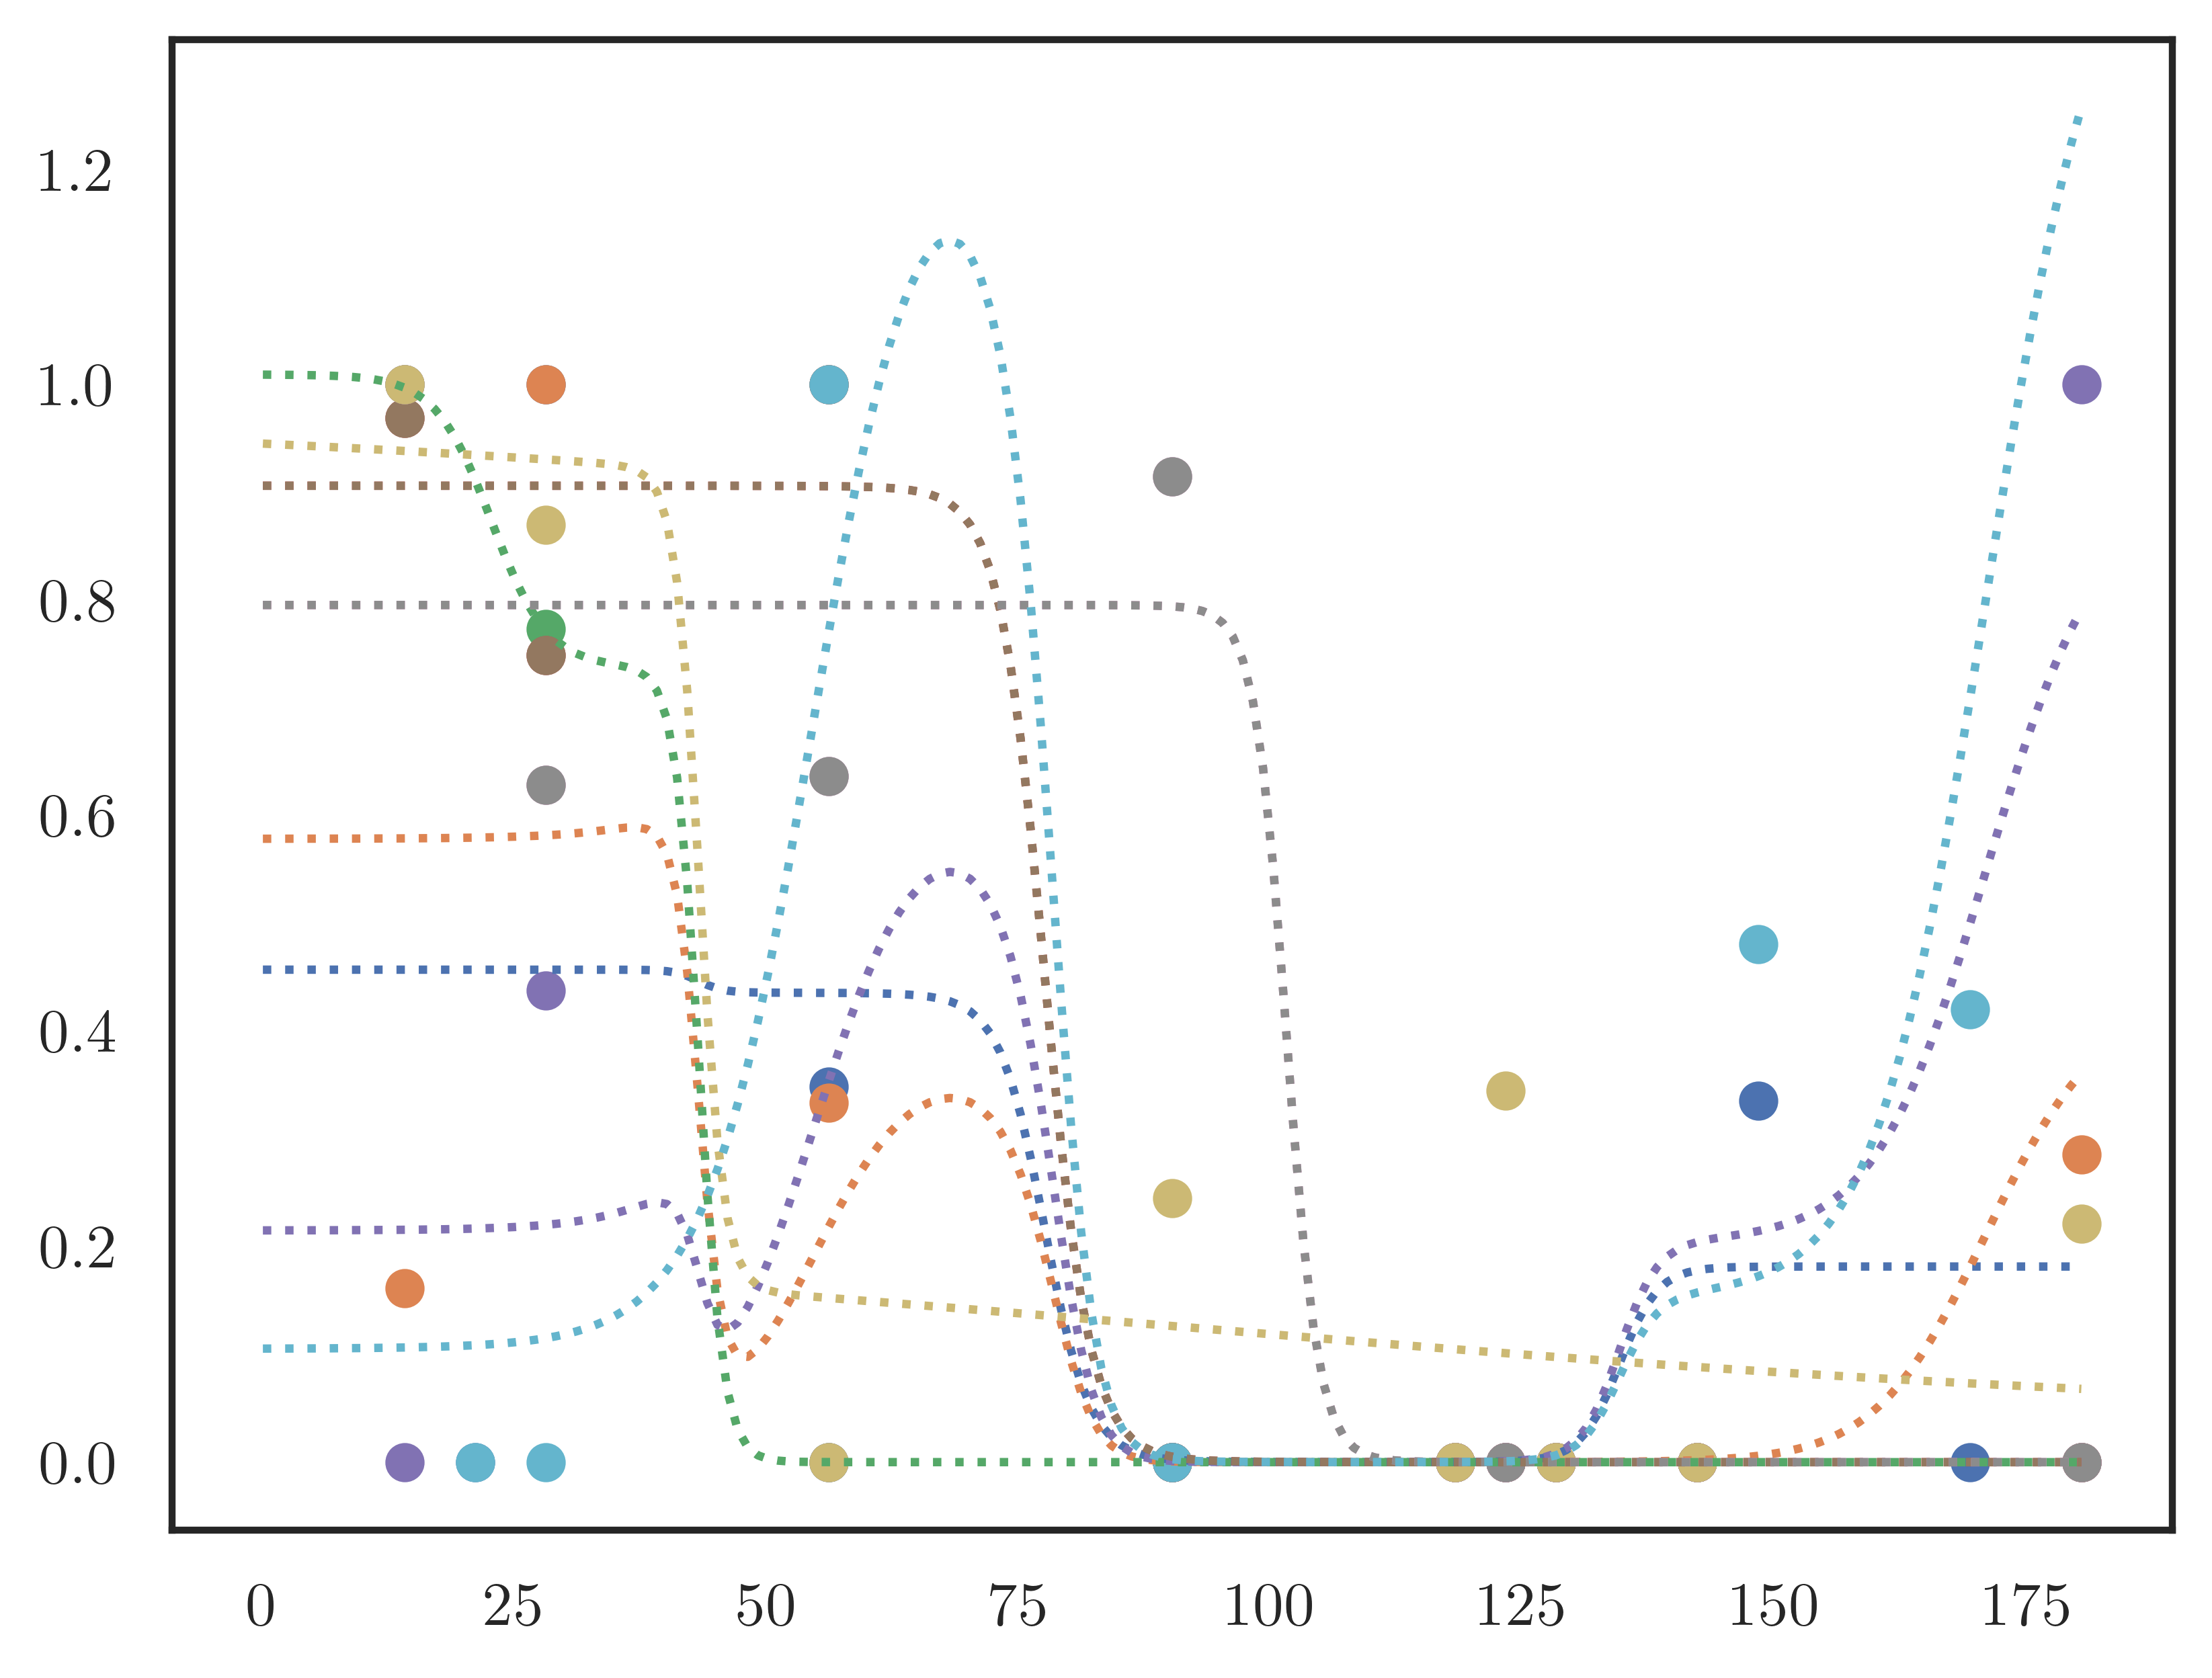

In [131]:
reconstruction_val = samples_val["beta_val"]["mean"].squeeze() @ basis_a.T * clone_scales_val.detach().numpy()
#Show reconstruction on validation

m = 10
palette = sns.color_palette(n_colors=m)

for i in range(m):
    idx = np.random.randint(0,len(clone_patterns_padded_allo_val))
    plt.scatter(np.arange(0,181), clone_patterns_padded_allo_val[idx,:].detach().numpy(), color = palette[i])
    plt.plot(np.arange(0,181), reconstruction_val.numpy()[idx,:], ls = ':', color = palette[i])
plt.show()

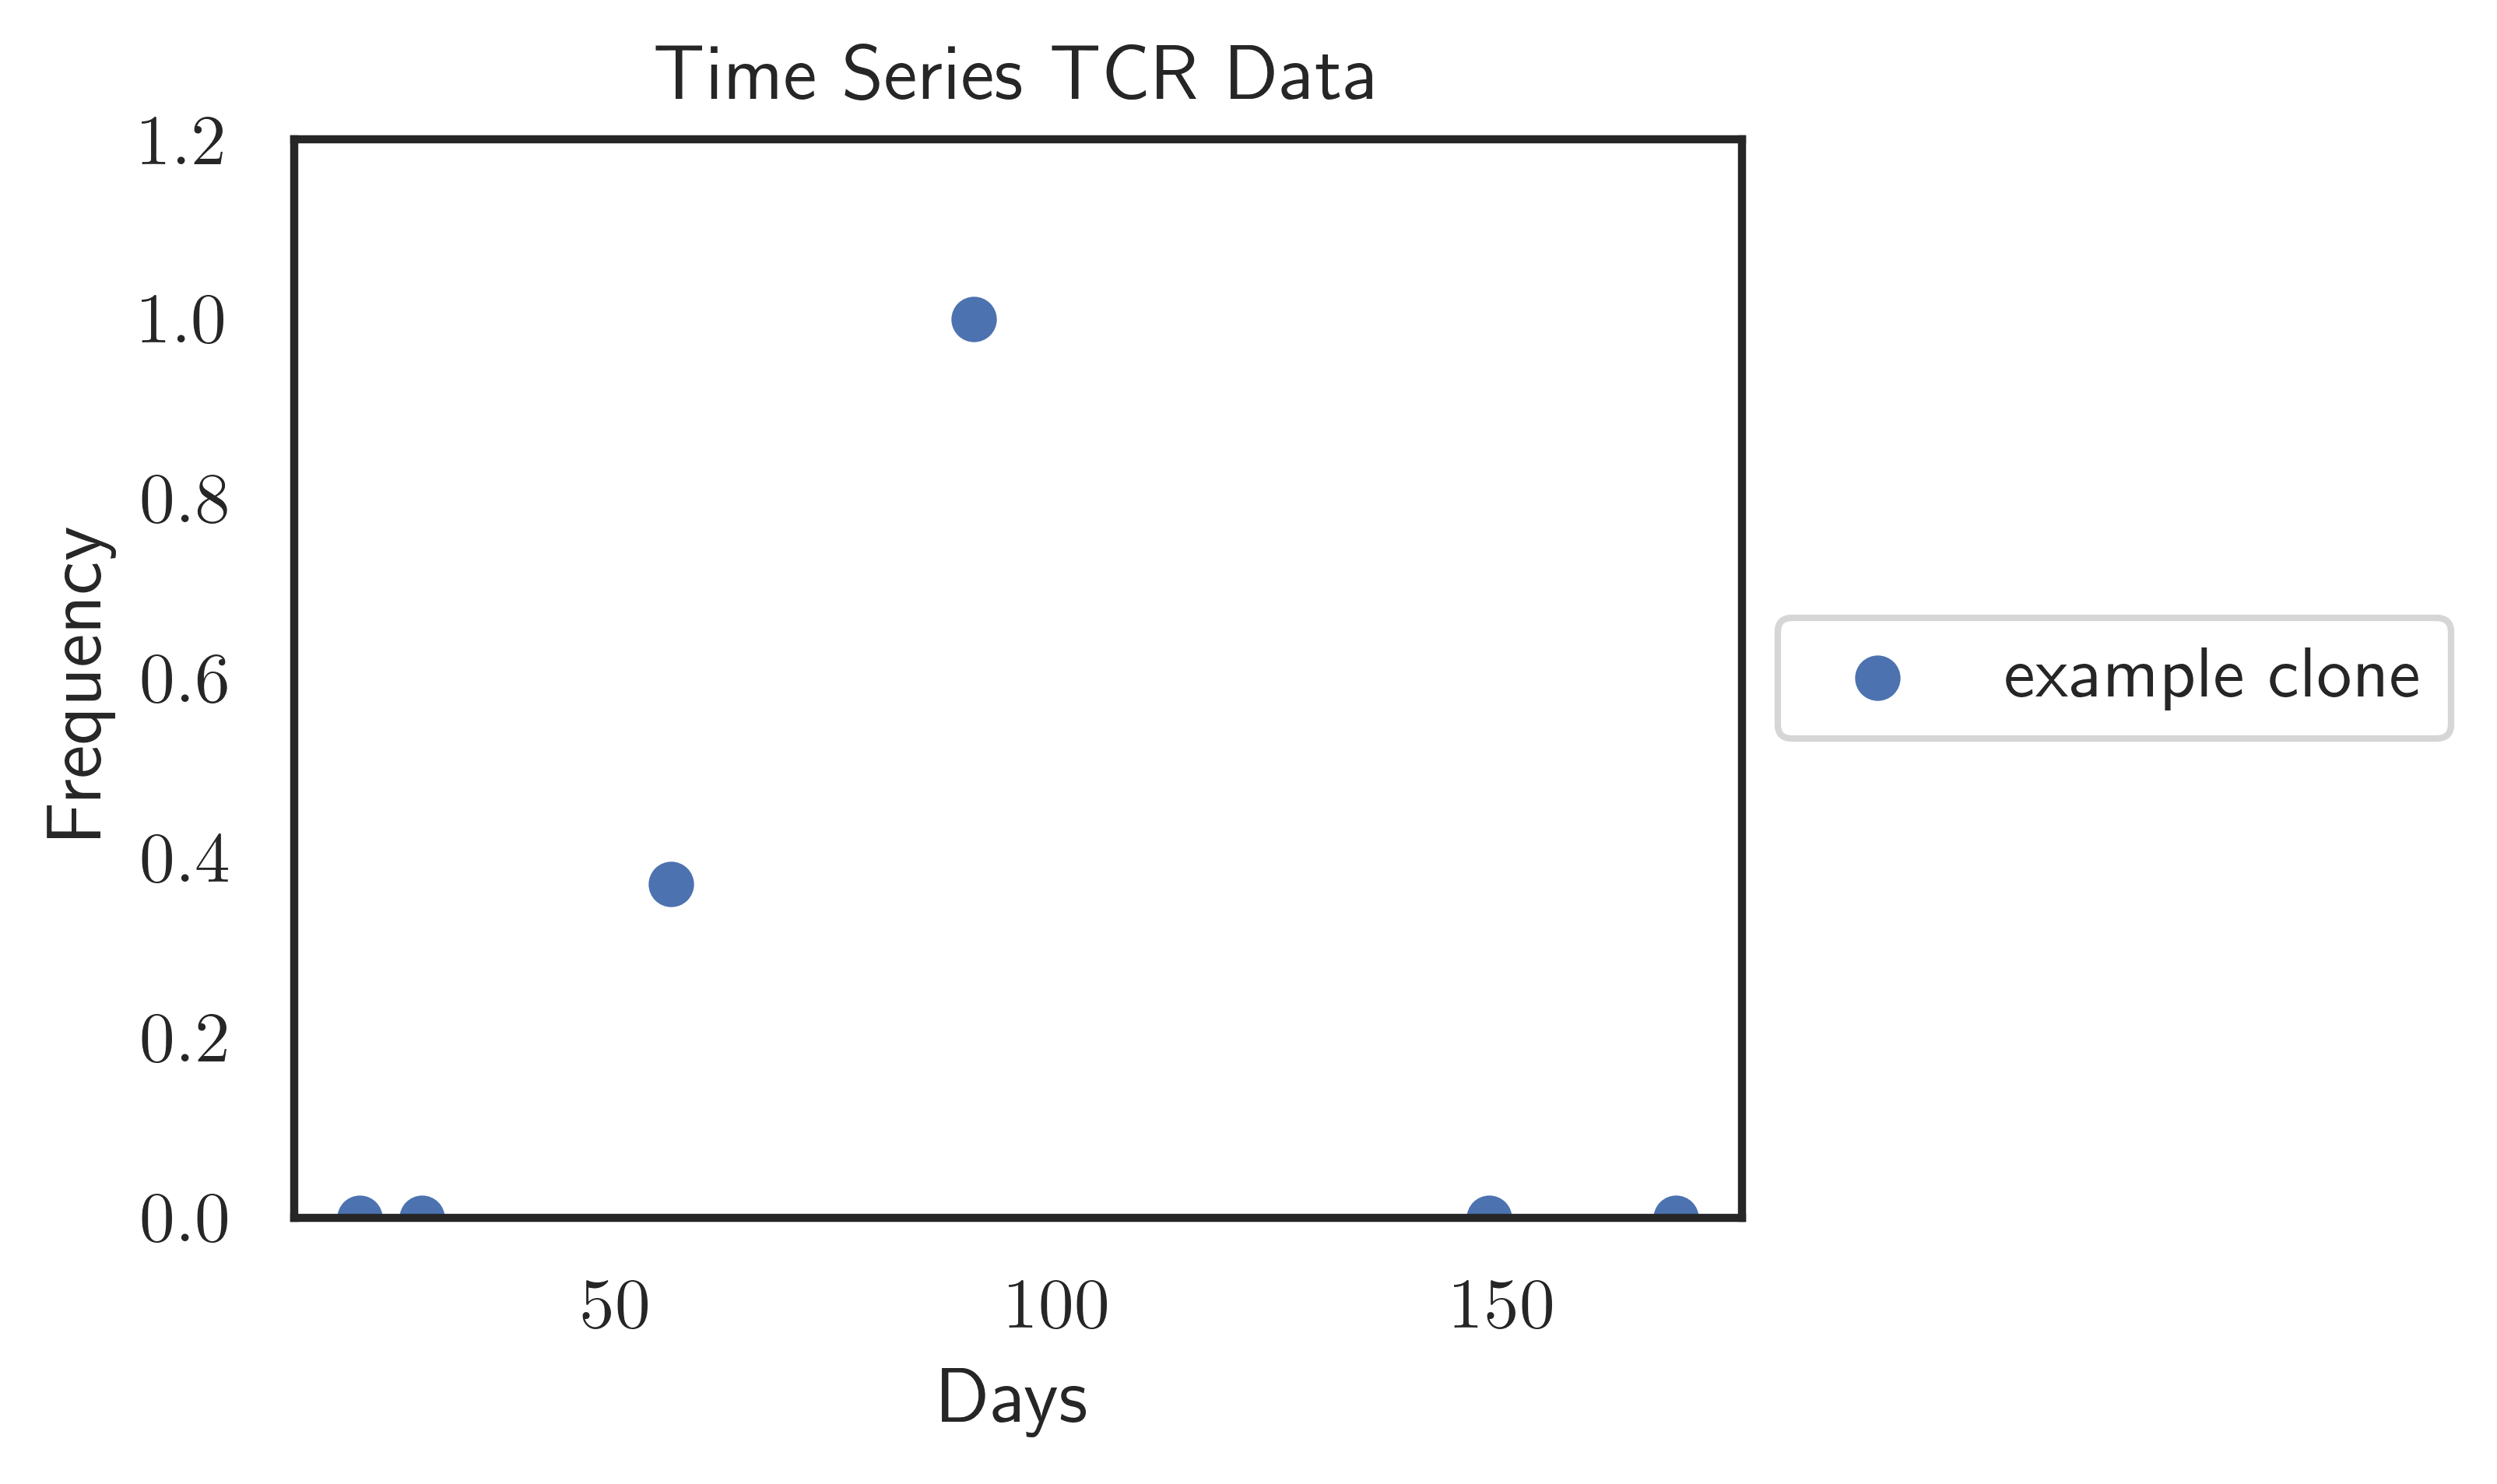

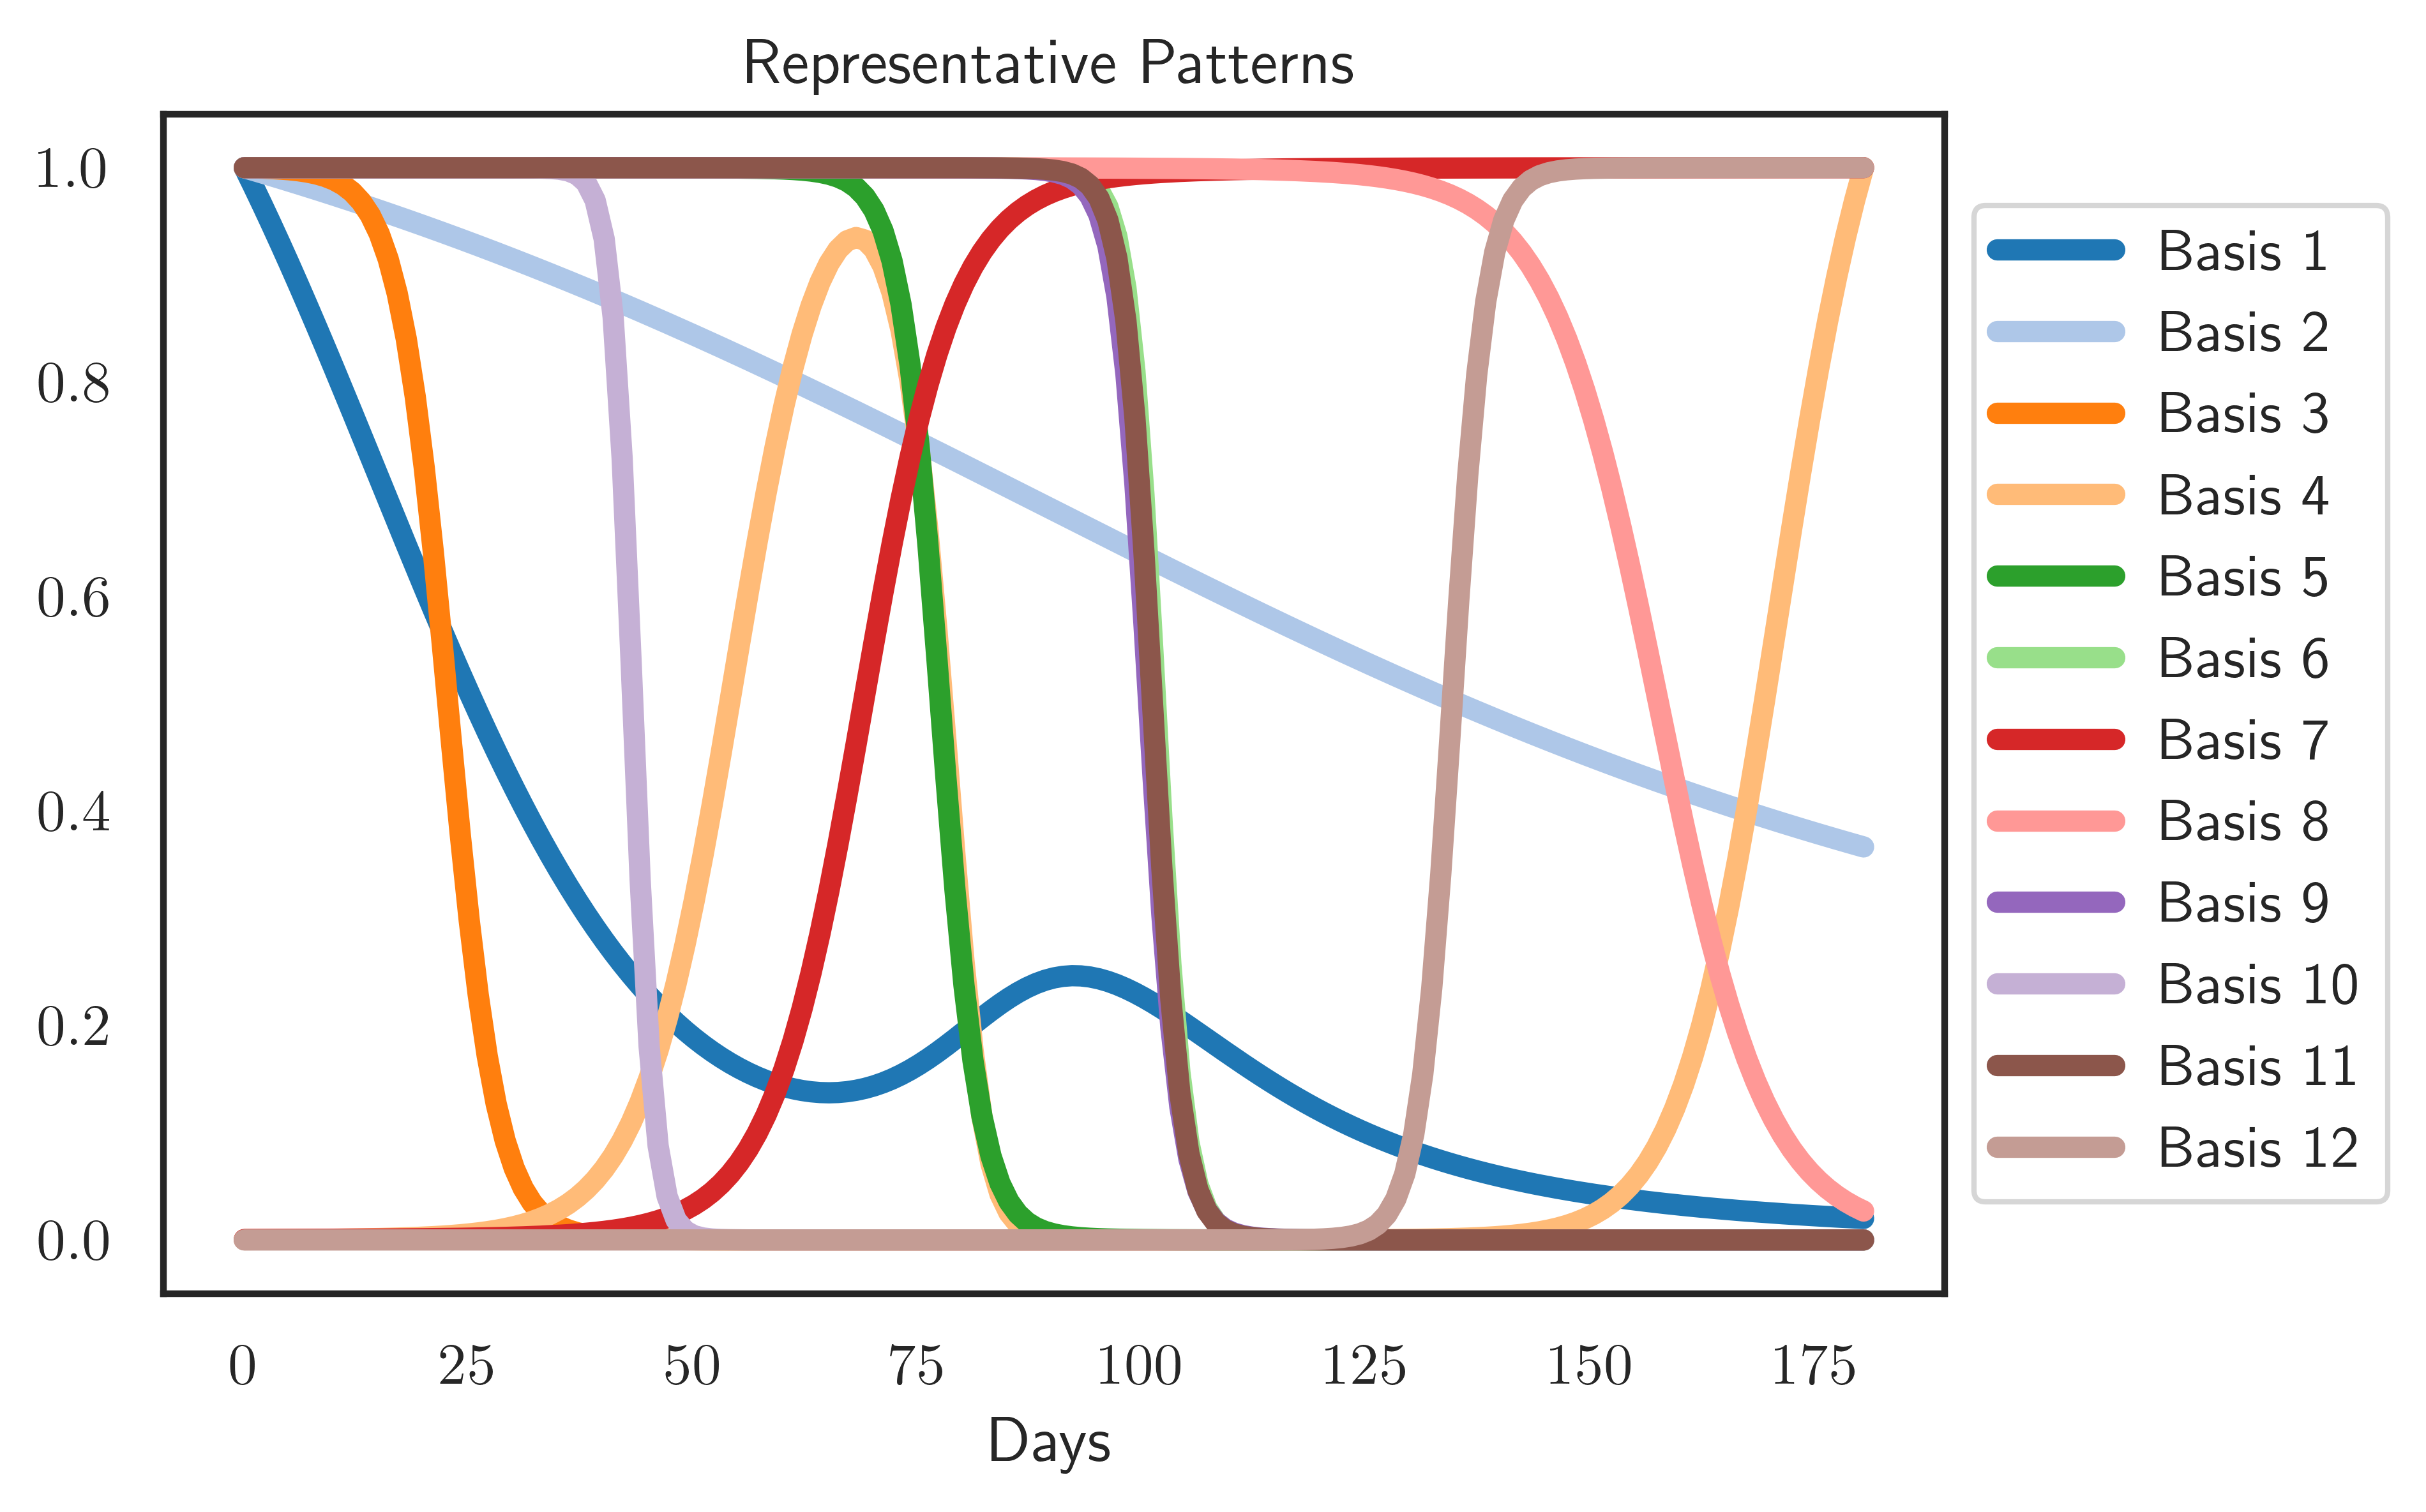

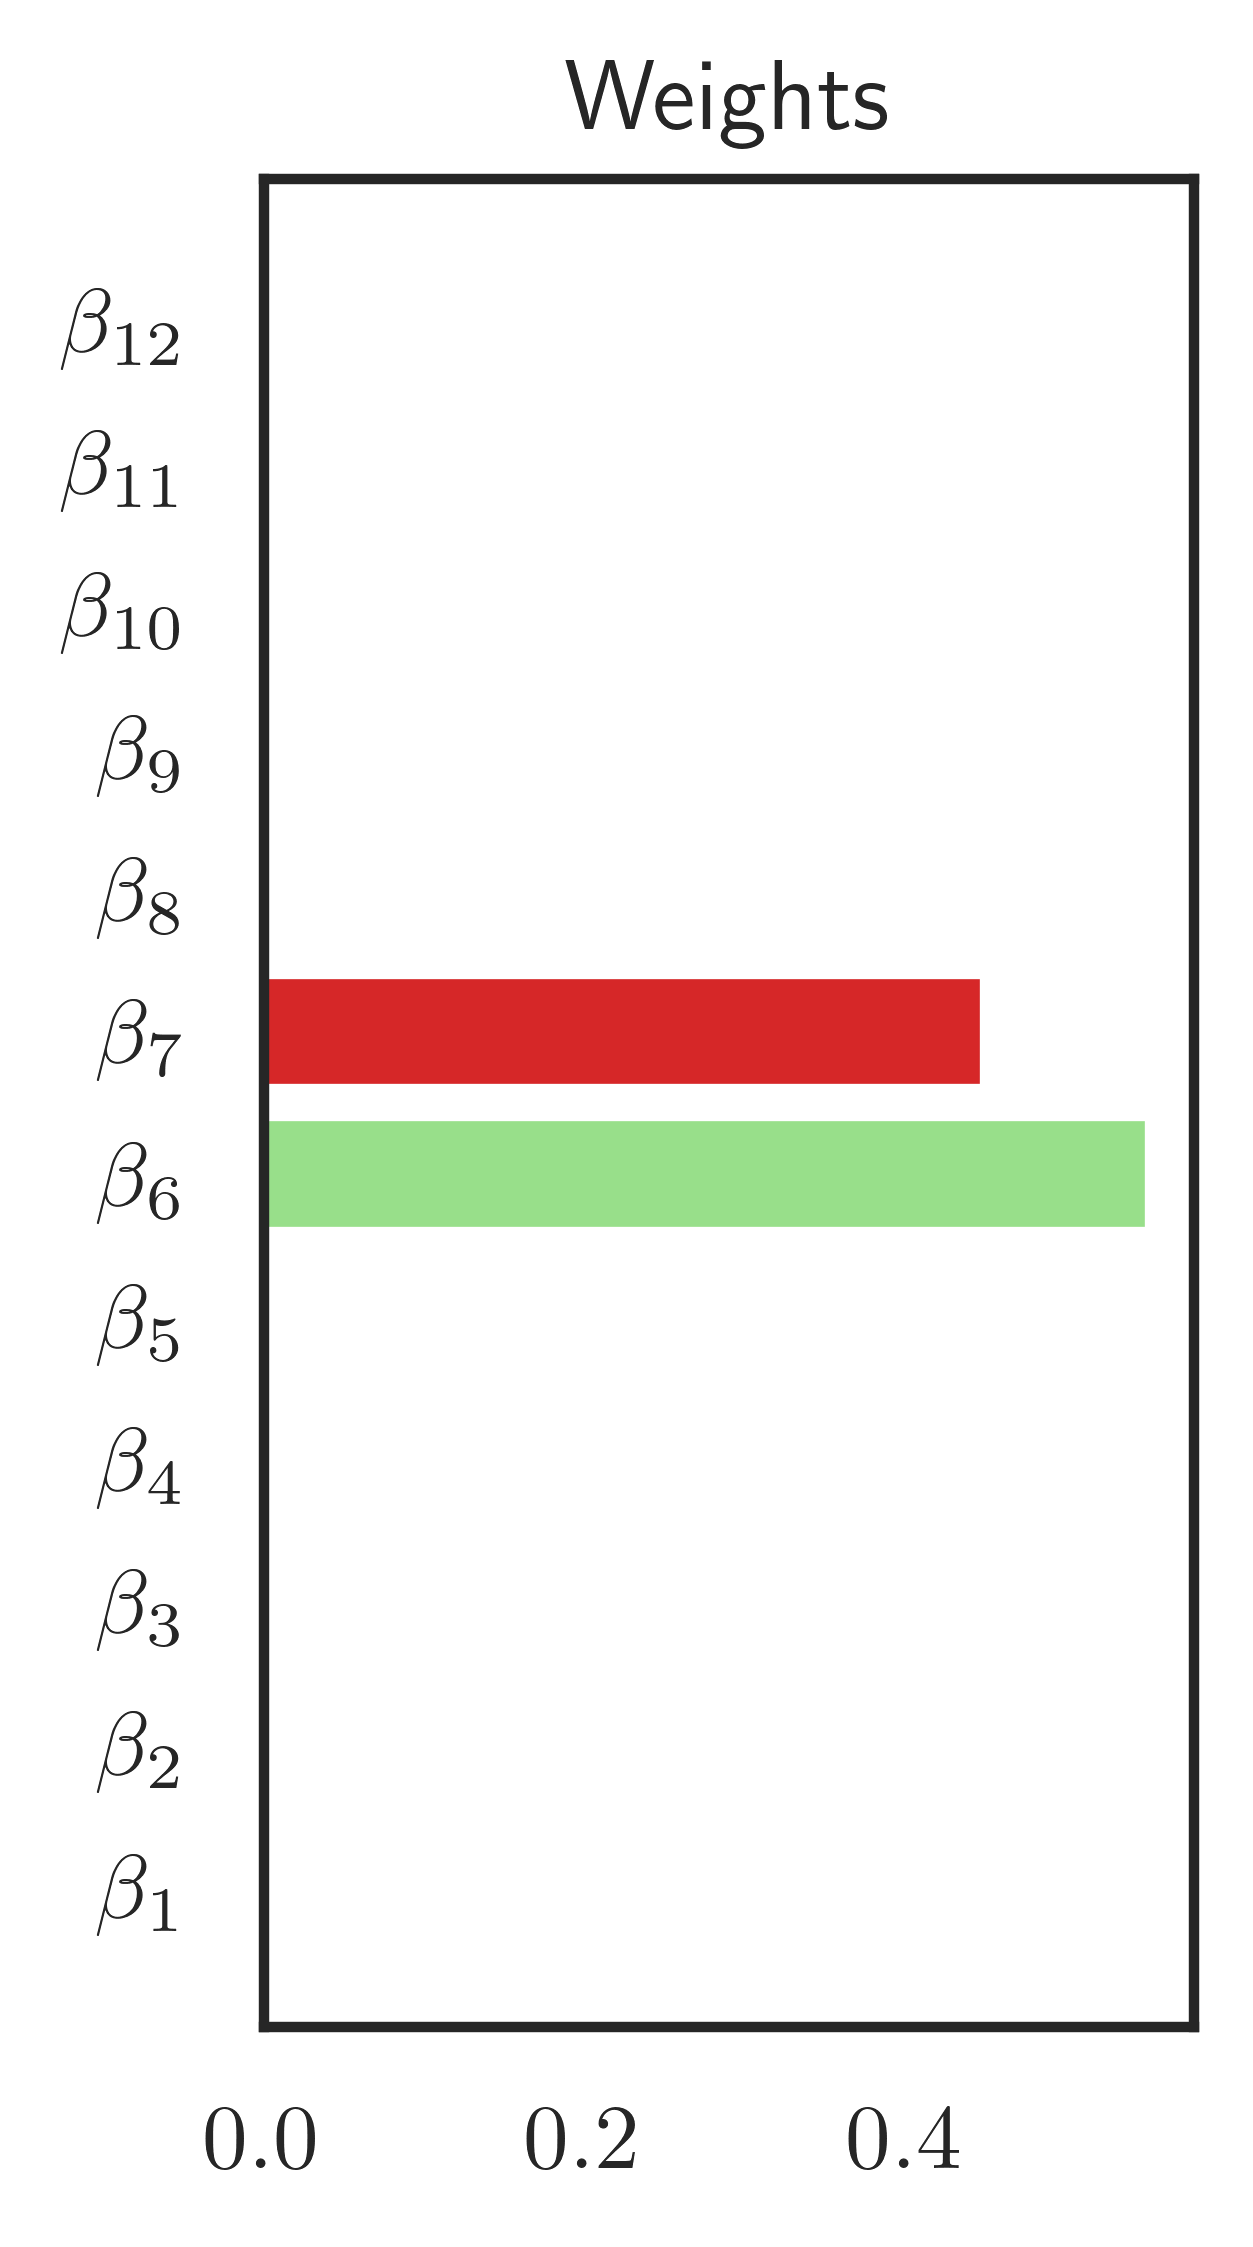

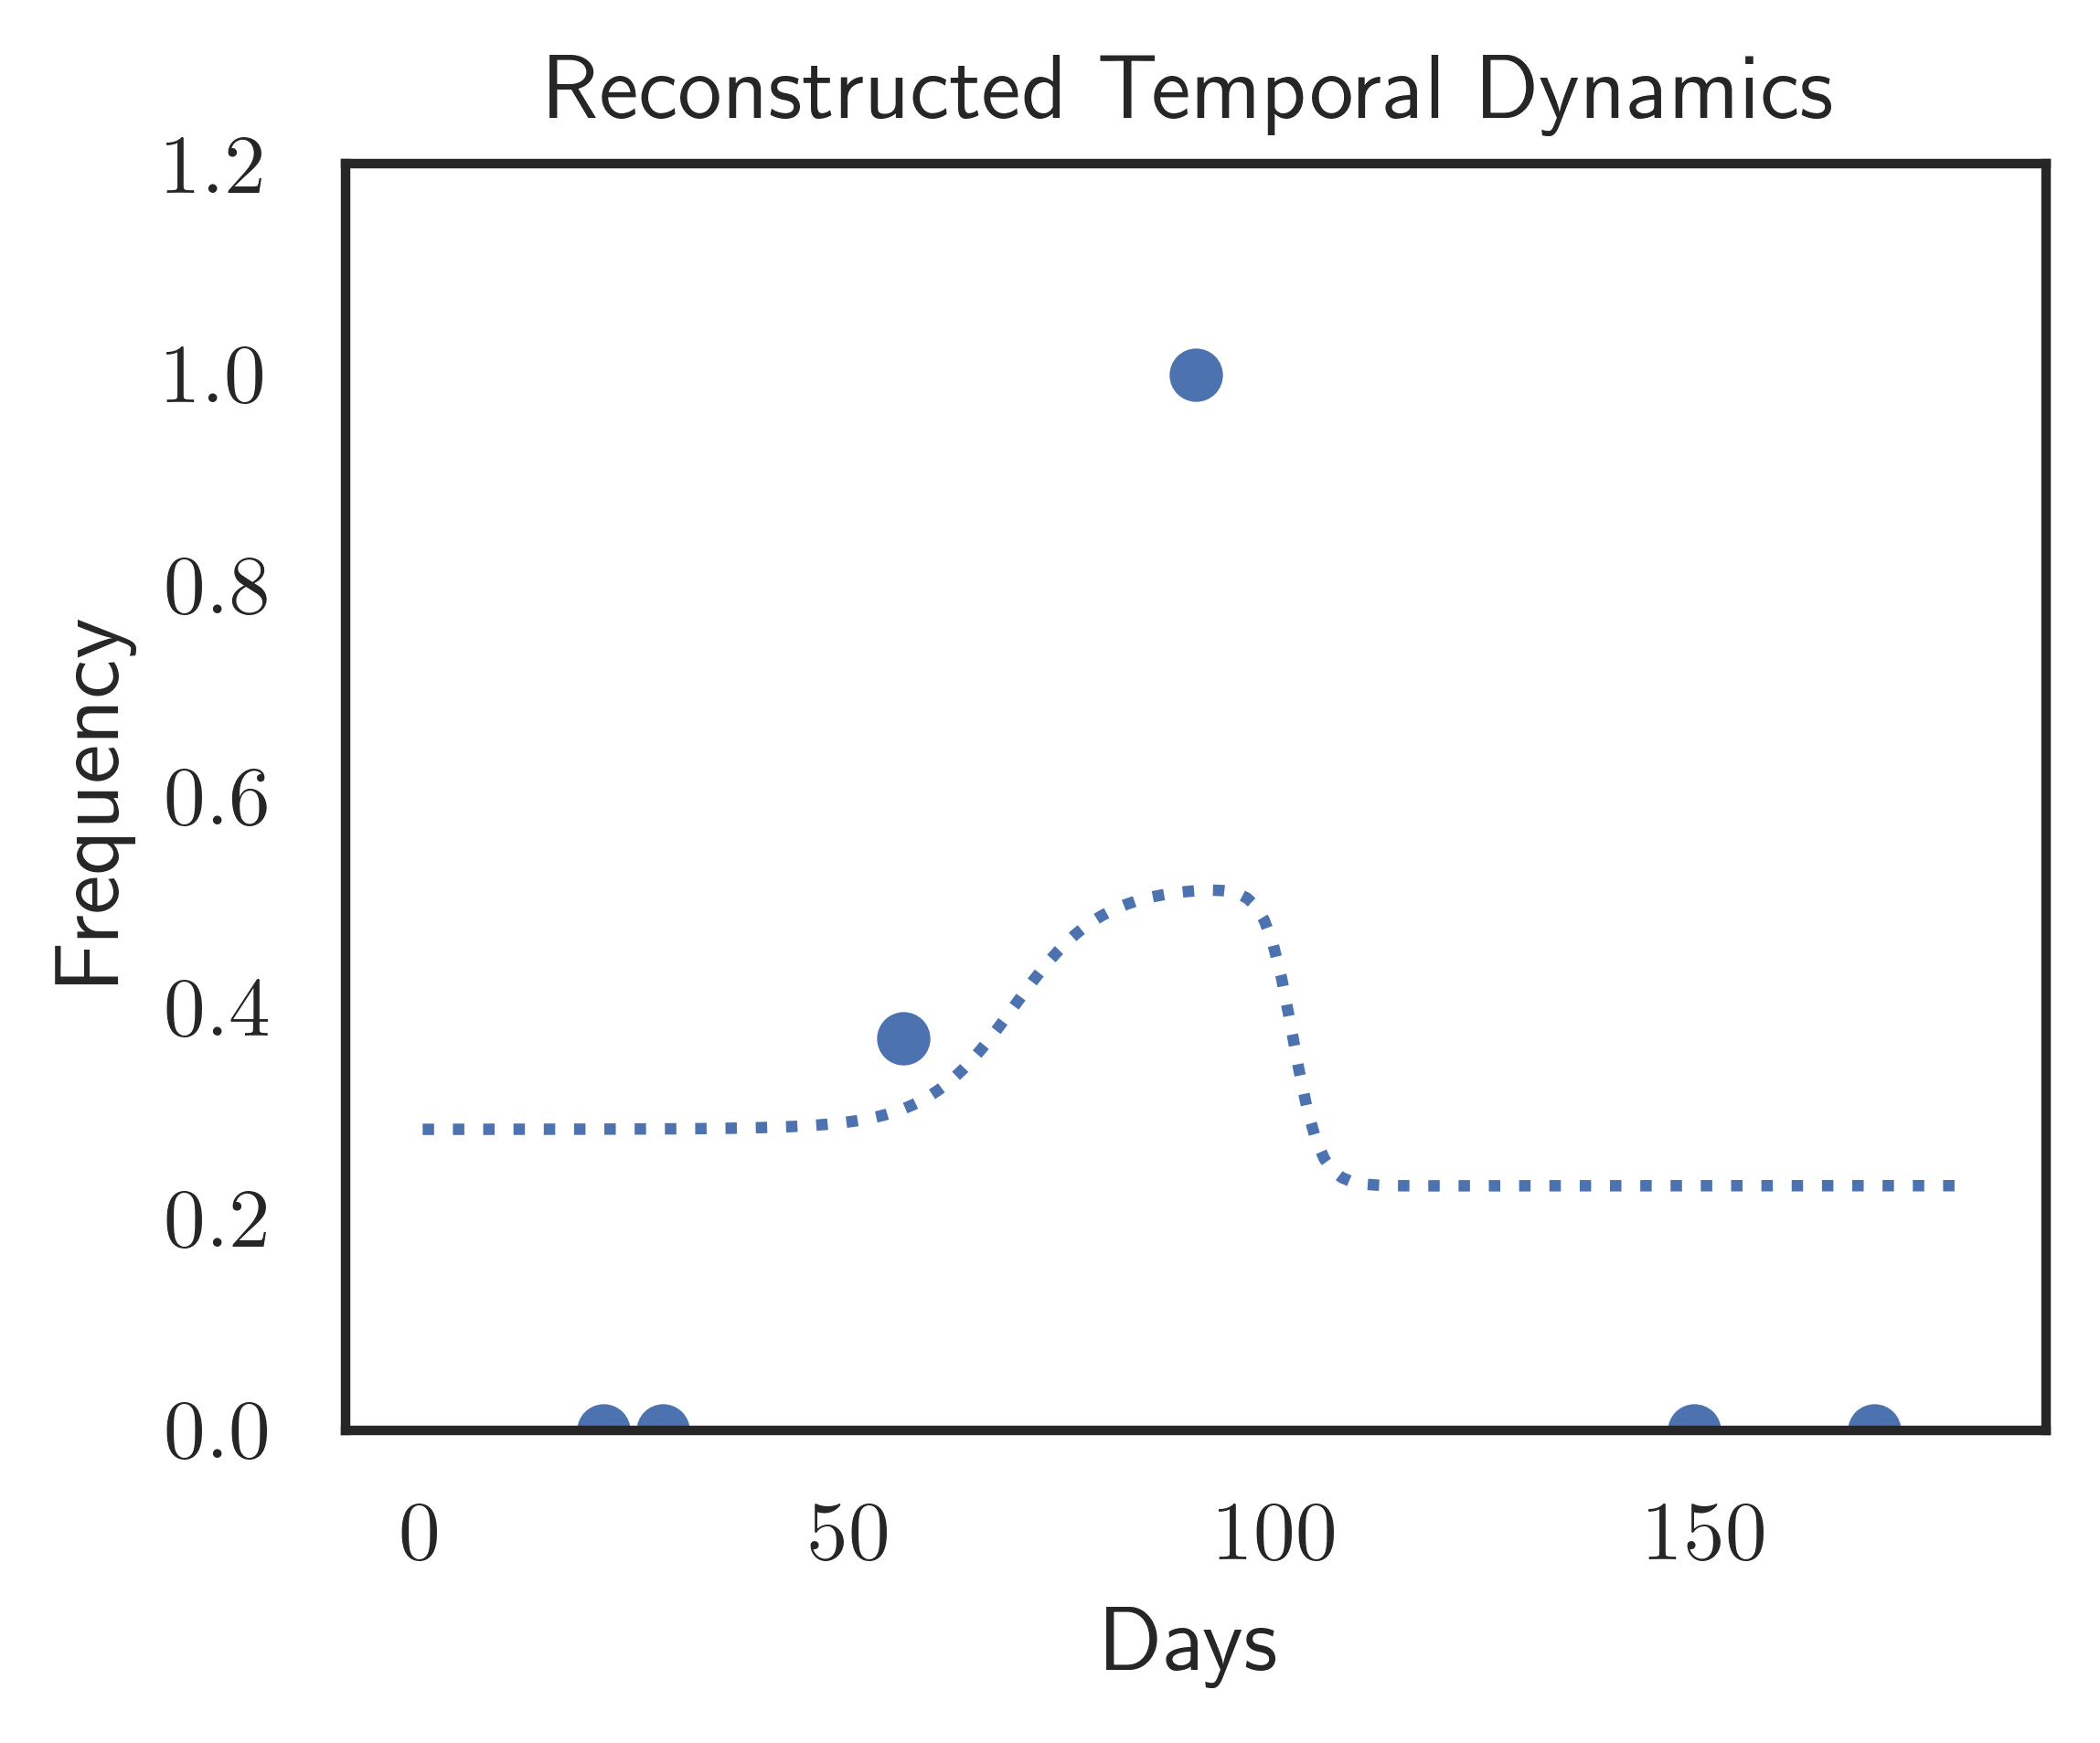

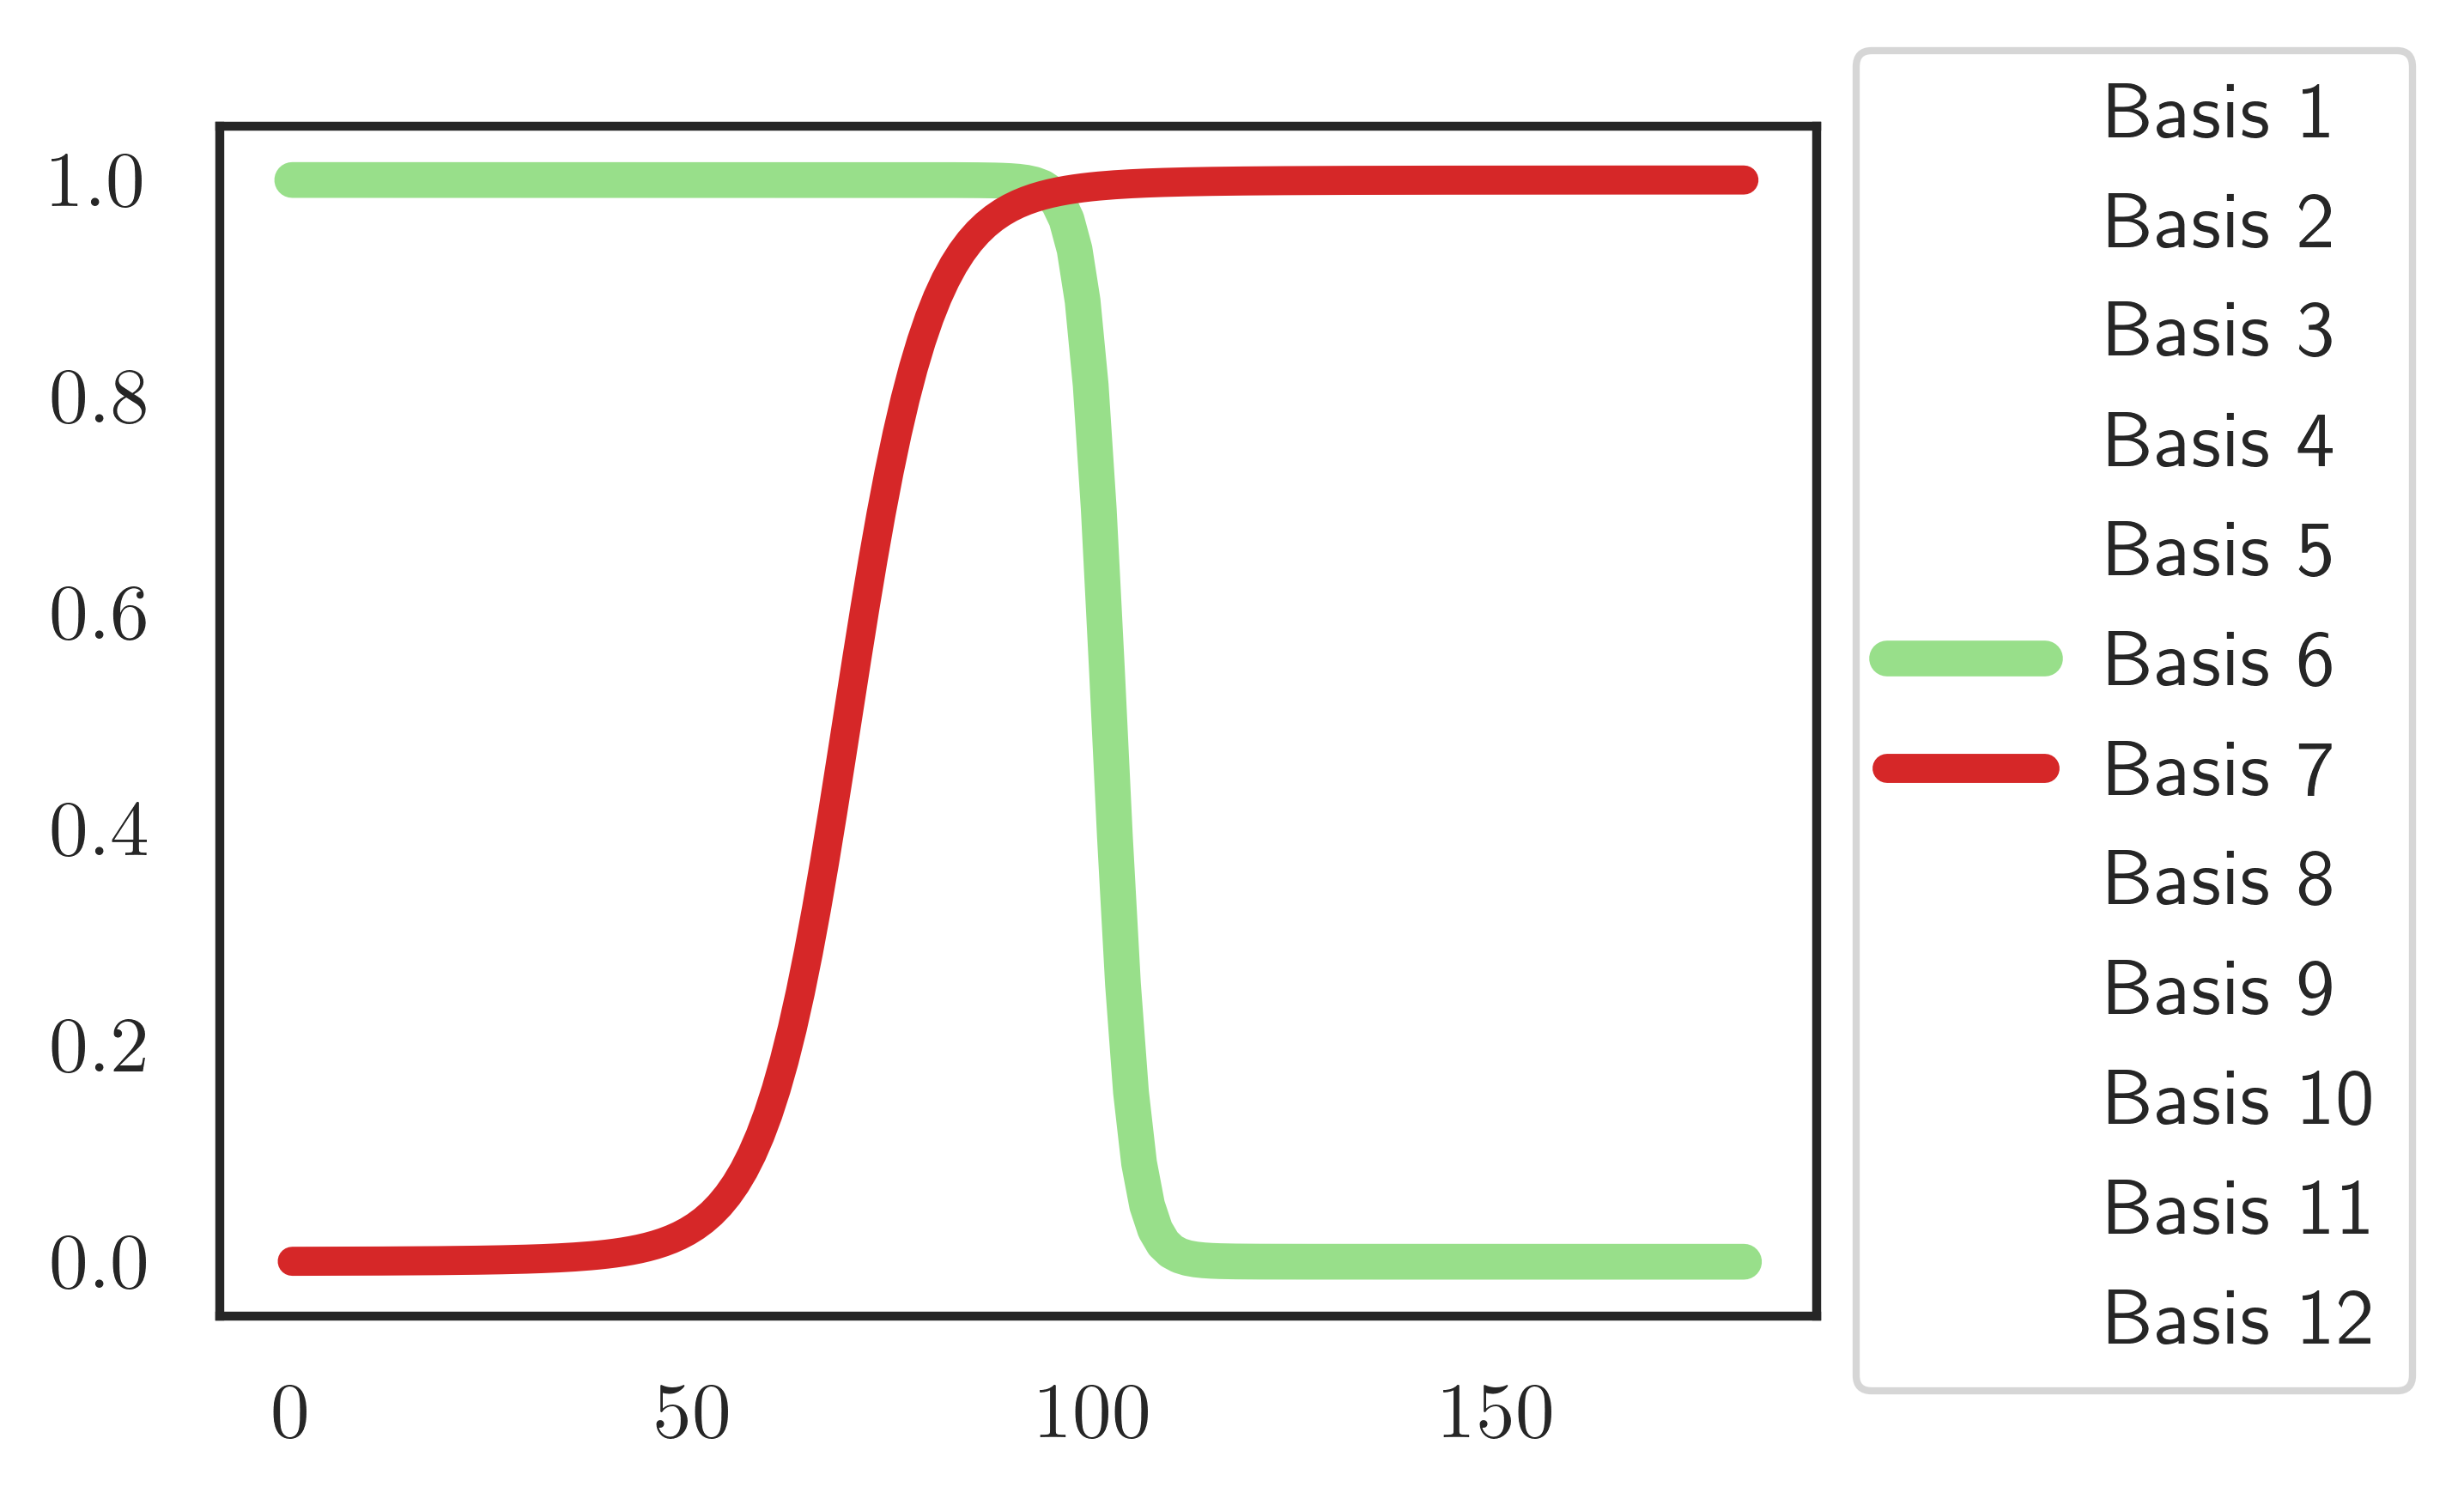

In [132]:


#Uncomment below to get the quantiles
# reconstruction_q05 = samples_a['_RETURN']['quantile05']
# reconstruction_q95 = samples_a['_RETURN']['quantile95']
reconstruction_std = samples_a['_RETURN']['std']

original = samples_a['obs']['mean']


plt.rcParams.update({'font.size': 18, "text.usetex":True })

m = 1
palette = sns.color_palette(n_colors = 1)[0]
idx = 0

#Scatter plot of the first clone pattern
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
idx = np.random.randint(0,len(clone_patterns_padded_allo_train))
ax.scatter(np.arange(0,181), clone_patterns_padded_allo_train[idx,:].detach().numpy(), color = palette)
ax.set_xlabel("Days")
ax.set_ylabel("Frequency")
ax.set_ylim([0,1.2])
ax.set_title("Time Series TCR Data")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels = ["example clone"])
plt.show()


sample_beta = samples_a["beta"]["mean"].squeeze()[idx,:]

#Plot the basis functions
fig, ax = plt.subplots(1,1, figsize = (6,4), dpi = 600)
for i in range(basis_a.shape[-1]):
    ax.plot(basis_a[:,i], linewidth = 4, color = sns.color_palette("tab20",n_colors=hyperparameters['n_basis'])[i])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels = ["Basis {}".format(x) for x in range(1,hyperparameters['n_basis']+1)])
ax.set_title("Representative Patterns")
ax.set_xlabel("Days")
plt.show()

#Plot the basis weights
fig, ax = plt.subplots(1,1, figsize = (2,4), dpi = 600)
ax.barh(y = np.arange(1,hyperparameters['n_basis'] + 1), width = sample_beta, color = sns.color_palette("tab20",n_colors=hyperparameters['n_basis']))
ax.set_yticks(np.arange(1,hyperparameters['n_basis']+1))
ax.set_yticklabels(["$\\beta_{"+str(x)+"}$" for x in range(1,hyperparameters['n_basis']+1)])
ax.set_title("Weights")
plt.show()


#Plot the fitted clone pattern
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
ax.scatter(np.arange(0,181), clone_patterns_padded_allo_train[idx,:].detach().numpy(), color = palette)
ax.plot(np.arange(0,181), reconstruction.numpy()[idx,:], ls = ':', color = palette)
ax.fill_between(np.arange(0,181), y1 = reconstruction.numpy()[idx,:] - reconstruction_std.numpy()[idx,:], y2 = reconstruction.numpy()[idx,:] + reconstruction_std.numpy()[idx,:], alpha = 0.2)
ax.set_xlabel("Days")
ax.set_ylabel("Frequency")
ax.set_title("Reconstructed Temporal Dynamics")
ax.set_ylim([0,1.2])
plt.show()


#Plot weighted Basis Functions. Line width is proportional to the weight of the basis function.
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
line_width = samples_a['beta']['mean'].squeeze()[idx,:]
line_width = line_width/line_width.max() * 5
for i in range(basis_a.shape[-1]):
    ax.plot(basis_a[:,i], linewidth = line_width[i], color = sns.color_palette("tab20",n_colors=hyperparameters['n_basis'])[i])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels = ["Basis {}".format(x) for x in range(1,hyperparameters['n_basis']+1)])
plt.show()

0.6005120449835755


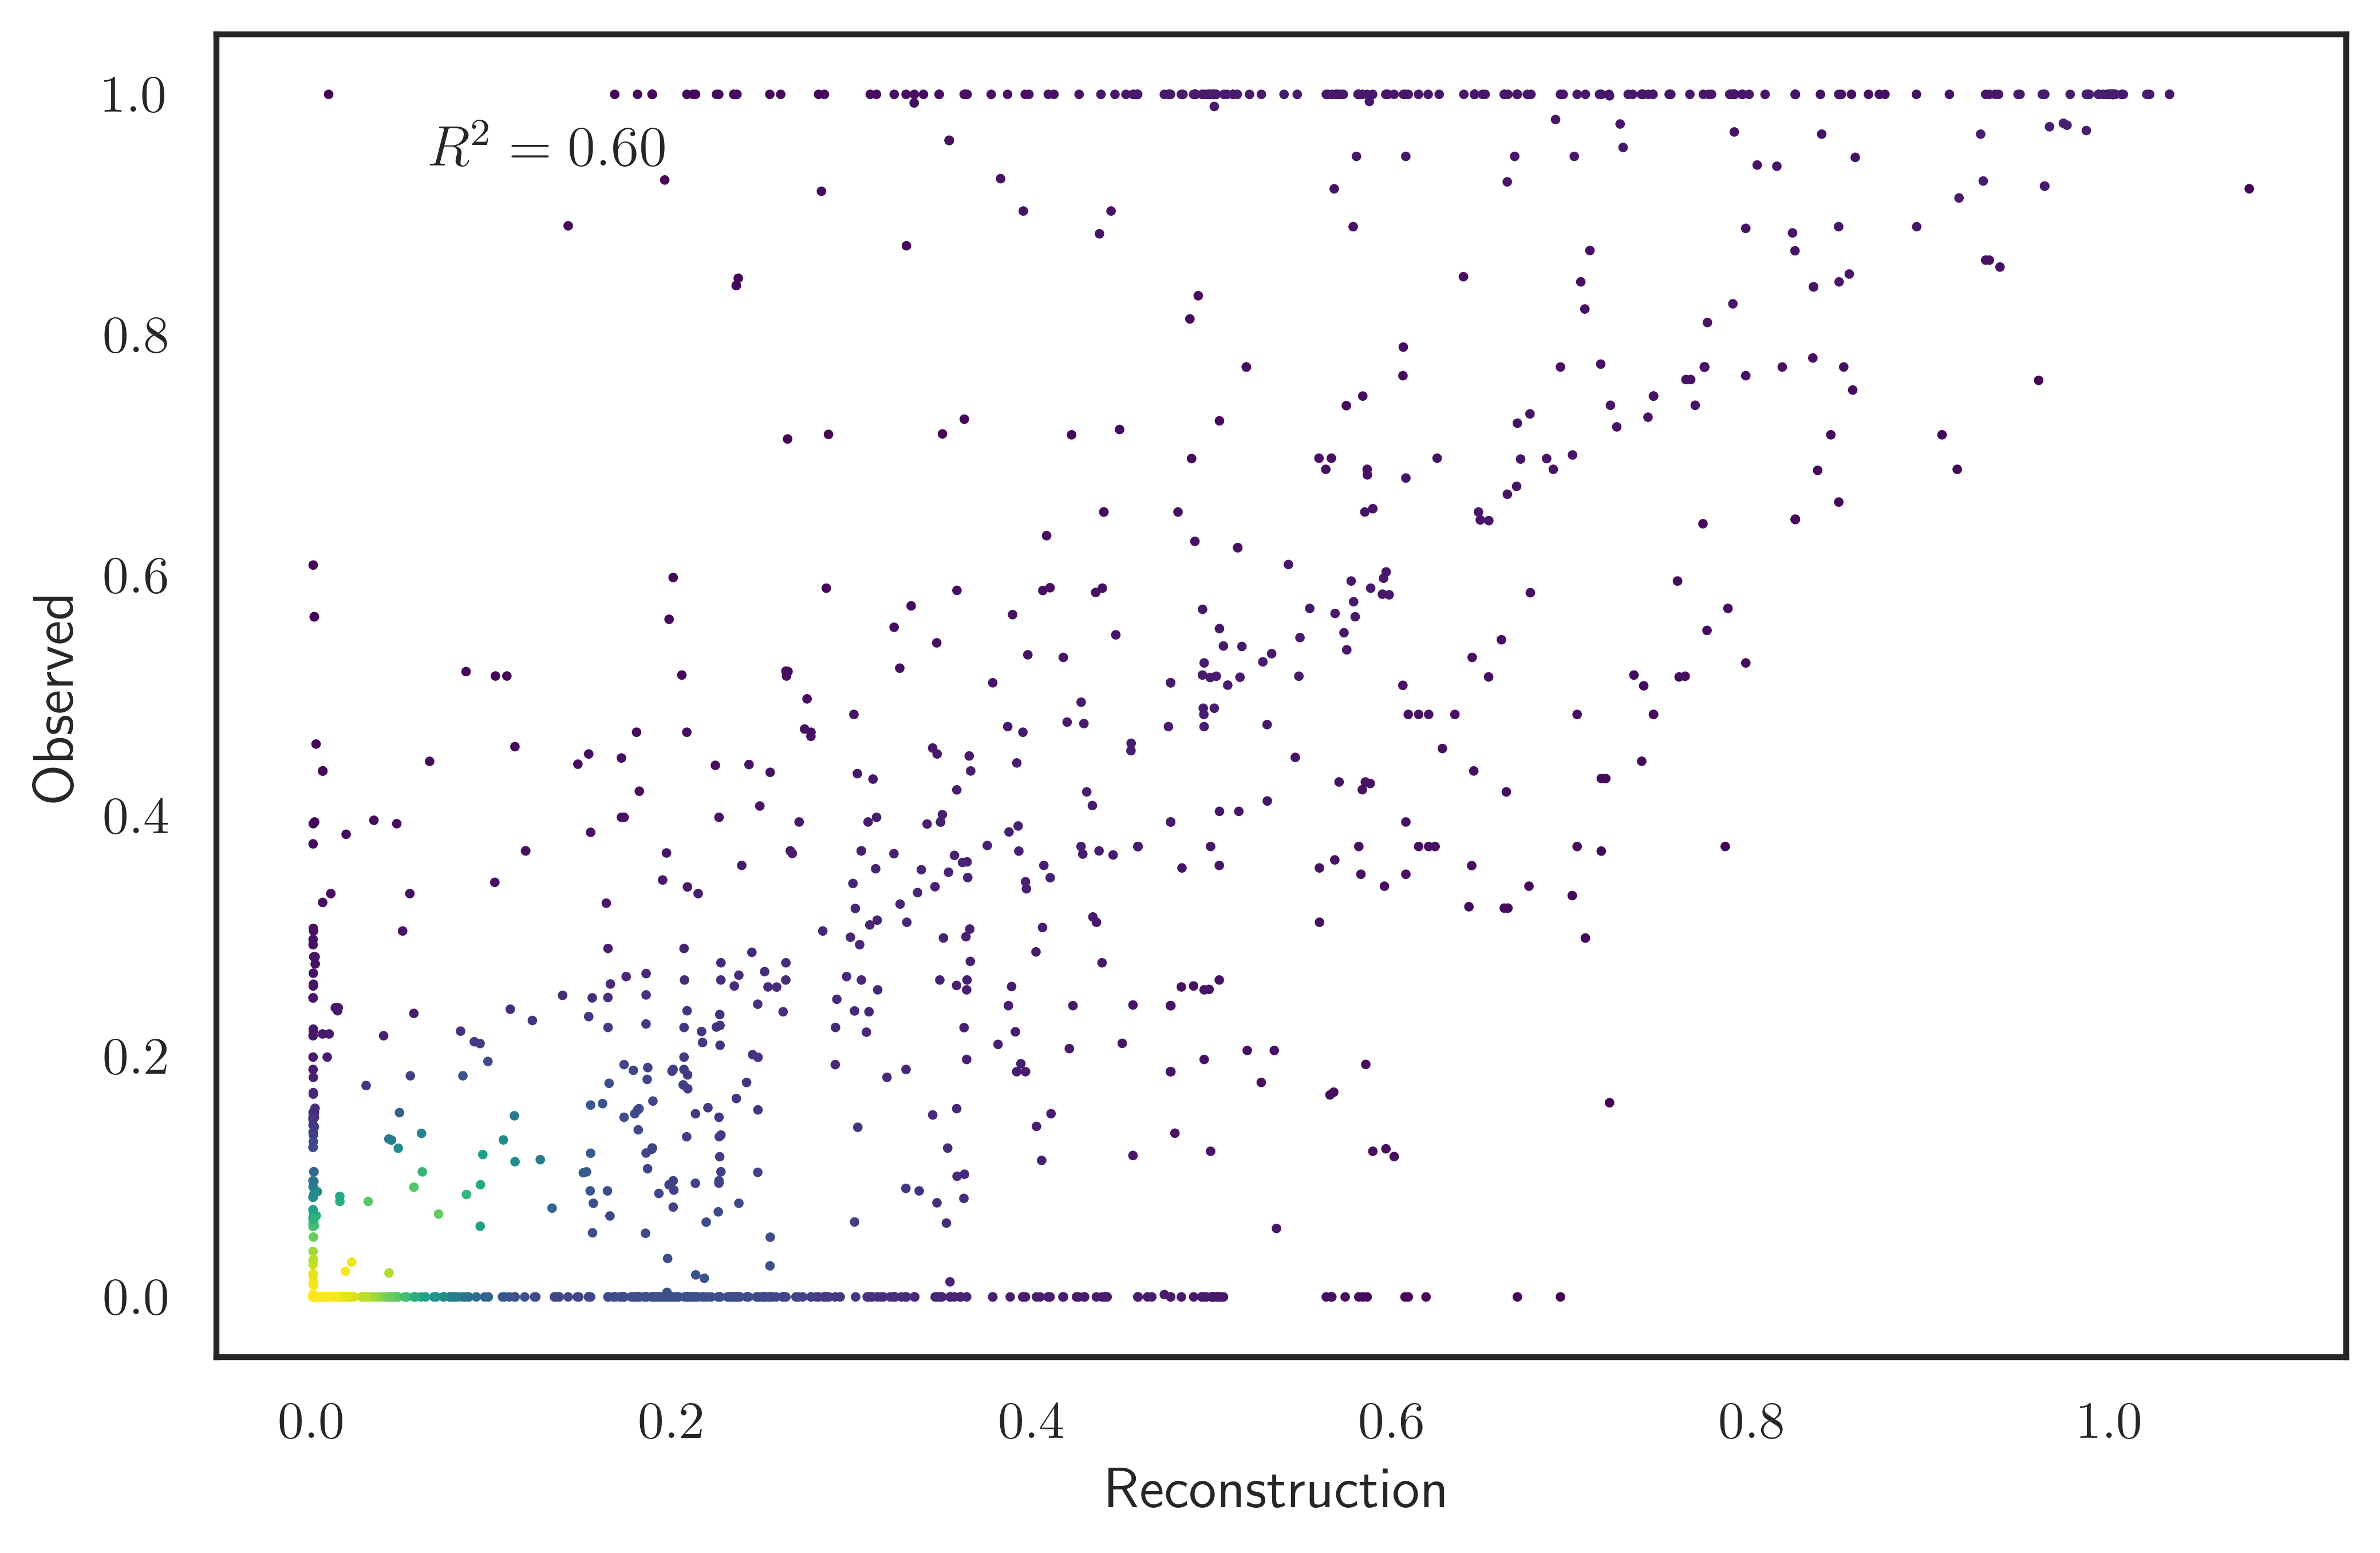

0.7515276528777142


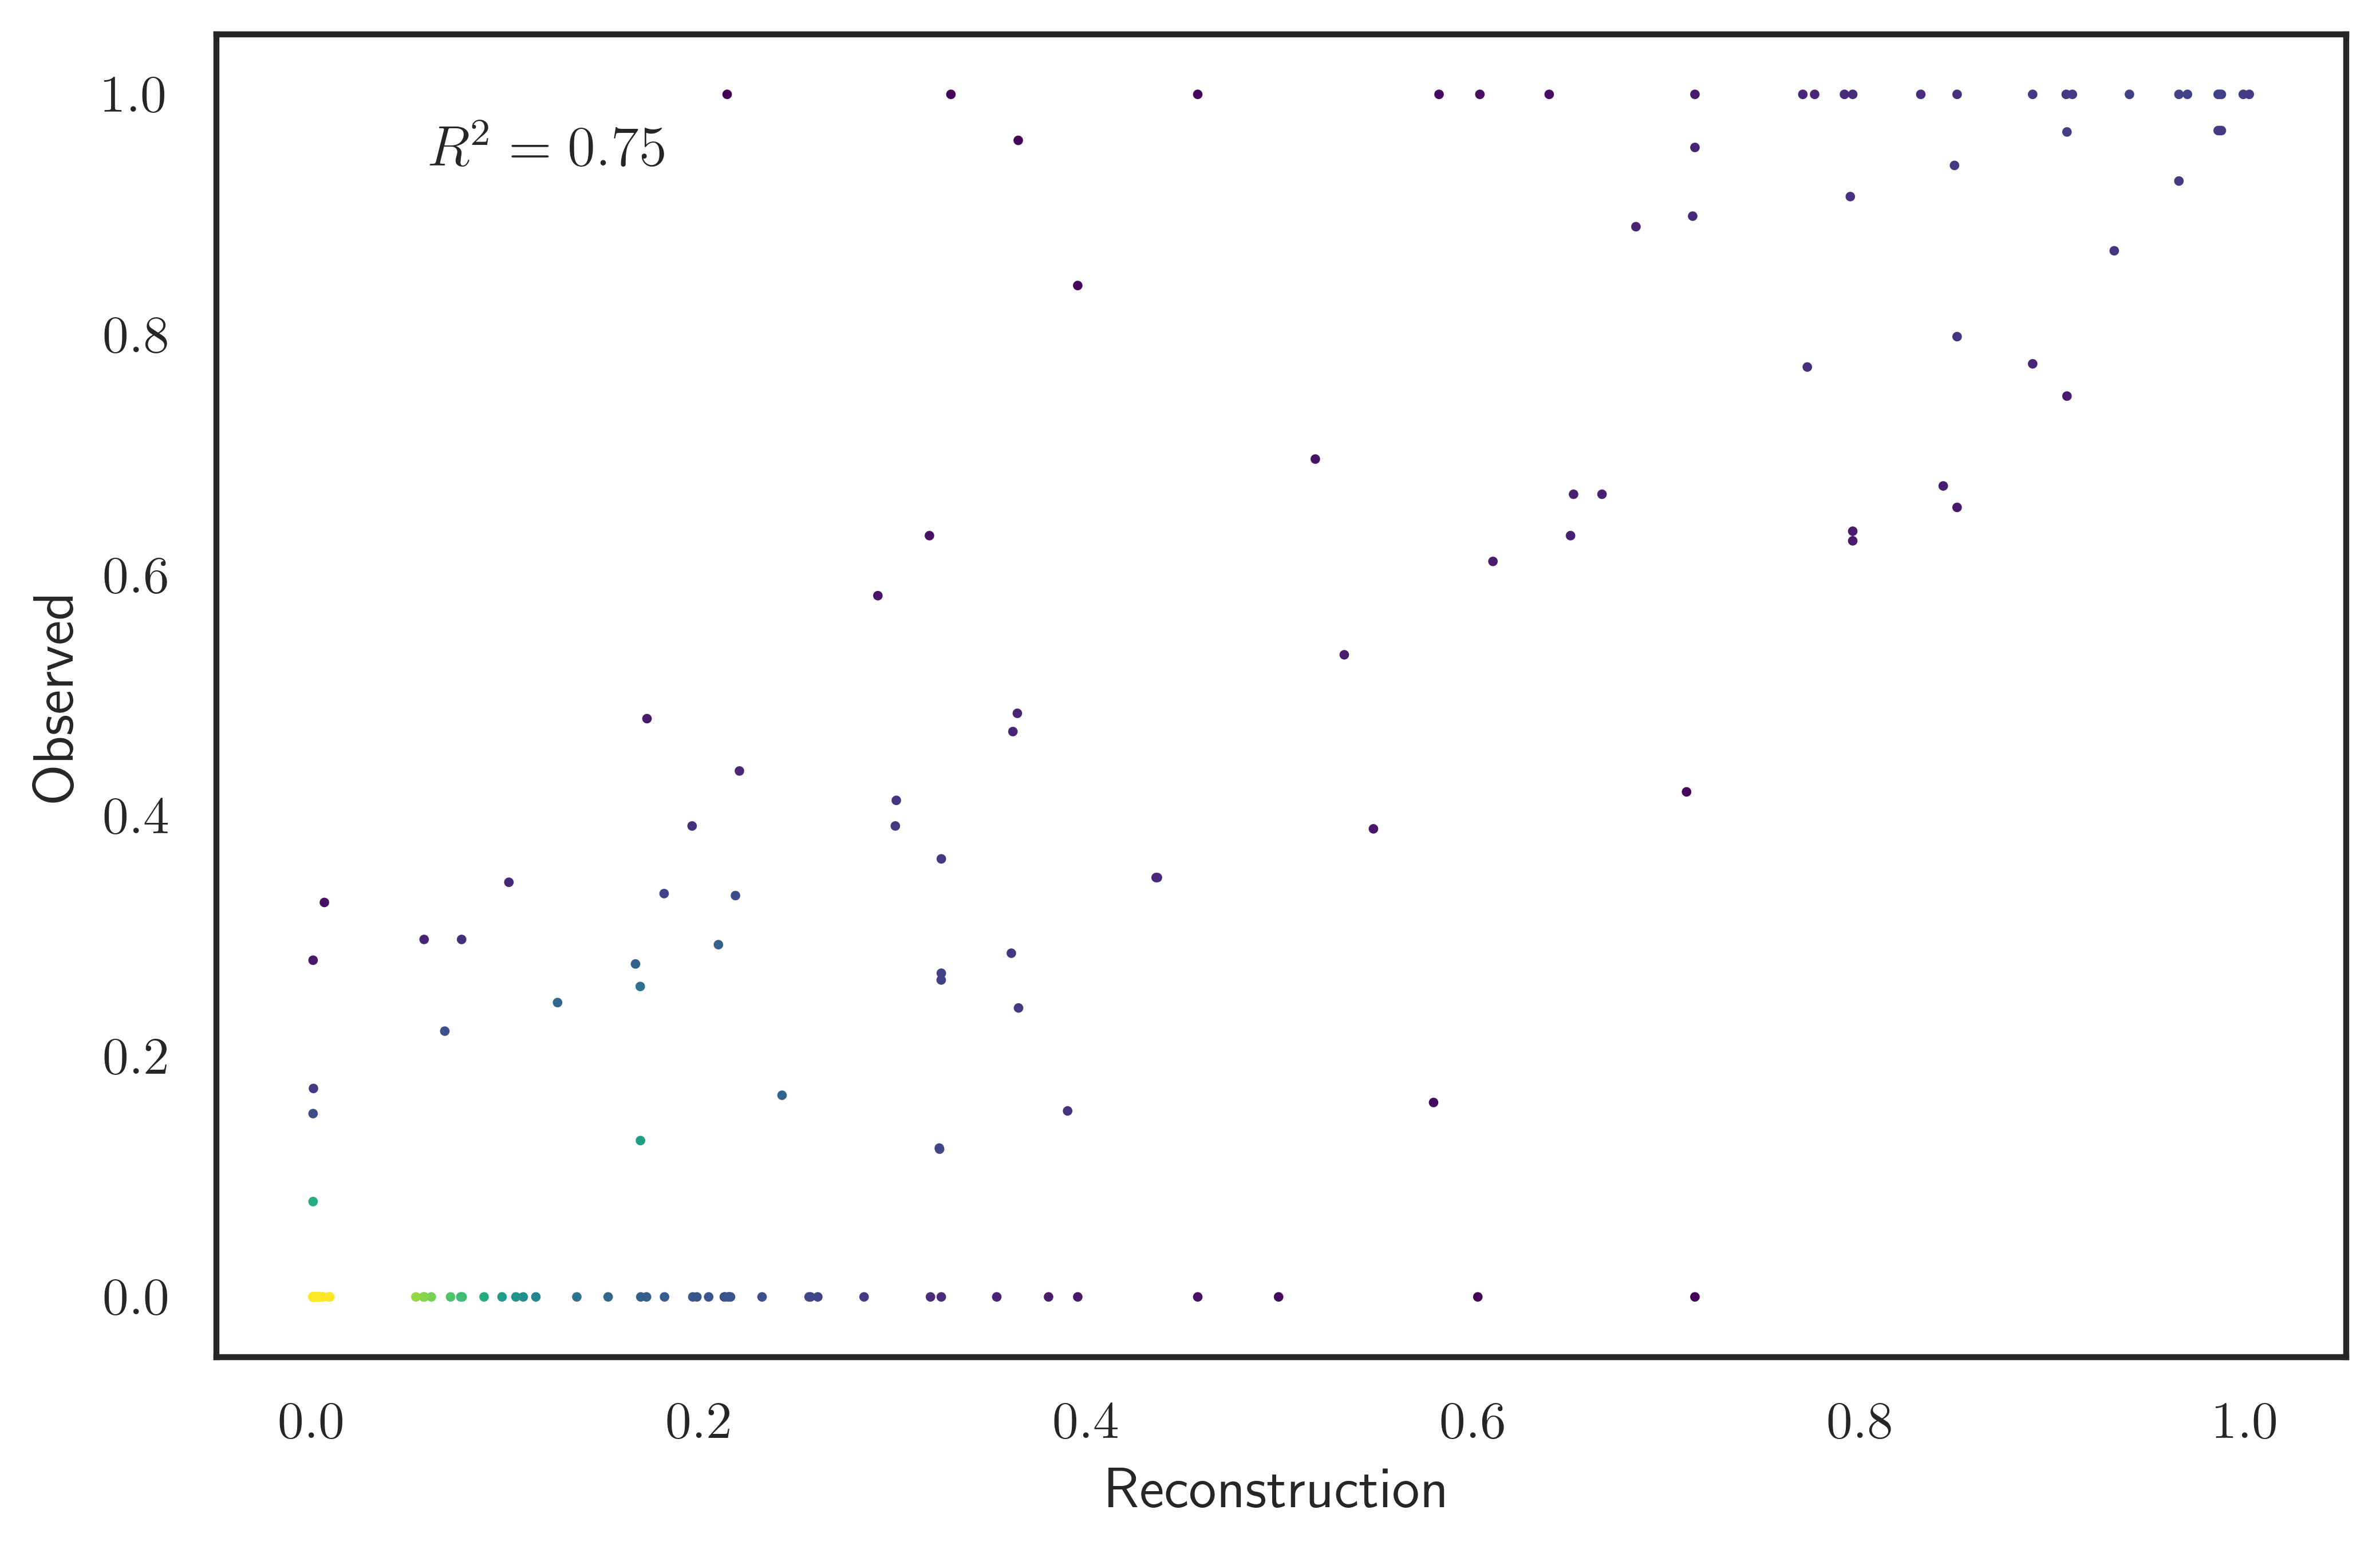

In [133]:

#To evaluate the model fit we want to compare the reconstruction vs the observed values for the training and validation data.
#Get reconstruction values and plot against observed and get R2 score
#Training Reconstruction Error
cmap = matplotlib.colormaps["viridis"]
reconstruction_val = samples_val["beta_val"]["mean"].squeeze() @ basis_a.T * model_val.gene_scales.detach().numpy()
reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

train_R2 = r2_score(clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())].flatten(),reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())].flatten())
print(train_R2)

d = np.vstack([reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())]])
kernel = gaussian_kde(d) #Fit Gaussian KDE to color the density of points
values = kernel(d)

fig, ax = plt.subplots(1,1, figsize = (8,5))

m = 5
ax.scatter(reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], s = 1,
            c = values, cmap = cmap)
ax.text(0.1, 0.9, f'$R^2 = {train_R2:.2f}$', transform=plt.gca().transAxes, fontsize=12)
ax.set_ylabel("Observed")
ax.set_xlabel("Reconstruction")
plt.show()


#Validation Reconstruction Error
fig, ax = plt.subplots(1,1, figsize = (8,5))
val_R2 = r2_score(clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())].flatten(),reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())].flatten())
print(val_R2)

d = np.vstack([reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())]])
kernel = gaussian_kde(d) #Fit Gaussian KDE to color the density of points
values = kernel(d)

m = 5
plt.scatter(reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], s = 1,
            c = values, cmap = cmap)
ax.text(0.1, 0.9, f'$R^2 = {val_R2:.2f}$', transform=plt.gca().transAxes, fontsize=12)
ax.set_ylabel("Observed")
ax.set_xlabel("Reconstruction")
plt.show()

Lets see how the model performs on some based on covariates

In [145]:
# matplotlib.rcParams['text.usetex'] = False

reconstruction = samples_a['_RETURN']['mean']
reconstruction_std = samples_a["_RETURN"]["std"]

cmap = matplotlib.colormaps["viridis"]
reconstruction_val = samples_val["beta_val"]["mean"].squeeze() @ basis_a.T * model_val.gene_scales.detach().numpy()
reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

#Uncomment detach.numpy() if newly fitted model
clone_scales_a = clone_scales_a#.detach().numpy()
clone_scales_a = np.expand_dims(clone_scales_a, axis = 0)


beta_a = samples_a['beta']['mean'].squeeze() #Get weights
beta_a = beta_a[:len(train_a_idx)] #filter to only the training set
beta_and_scale_a = np.concatenate([beta_a], axis = 1)
beta_and_scale_df_a = pd.DataFrame(beta_and_scale_a)
col_names = np.concatenate([np.linspace(1, hyperparameters['n_basis'], hyperparameters['n_basis'], dtype = int).astype(str), ["clone_scales"]])

beta_a_val = samples_val['beta_val']['mean'].squeeze() #Get val weights
beta_a_val = beta_a_val[:len(val_a_idx)] #filter to only the validation set
beta_and_scale_a_val = np.concatenate([beta_a_val], axis = 1) 
beta_and_scale_df_a_val = pd.DataFrame(beta_and_scale_a_val)
col_names = np.concatenate([np.linspace(1, hyperparameters['n_basis'], hyperparameters['n_basis'], dtype = int).astype(str), ["clone_scales"]])


#Perform clustering on the basis weights and clone scales. Can be displayed with UMAP or Clustermaps. Not cricitical for analysis.
adjacency = kneighbors_graph(np.concatenate([beta_and_scale_df_a.values,beta_and_scale_df_a_val.values]), 
                             n_neighbors = 30, 
                             mode = "distance" , 
                             metric = "euclidean")


#Cluster with Louvain
louvain = Louvain(.05)
labels_allo = louvain.fit_predict(adjacency)
labels_allo_train = labels_allo[:beta_and_scale_a.shape[0]]
labels_allo_val = labels_allo[beta_and_scale_a.shape[0]:]

data_filt_a_train = data_filt_a.iloc[train_a_idx,:].reset_index(drop = True)
data_filt_a_train["Data"] = "Training"
data_filt_a_val = data_filt_a.iloc[val_a_idx,:].reset_index(drop = True)
data_filt_a_val["Data"] = "Validation"

data_filt_a_cat = pd.concat([data_filt_a_train, data_filt_a_val])
data_filt_a_cat["Cluster"] = labels_allo

data_filt_a_cat = data_filt_a_cat.reset_index(drop = True)

data_filt_a_cat_all = pd.concat([data_filt_a_cat,pd.DataFrame(np.concatenate([beta_a,beta_a_val]))], axis = 1 , join = "inner").drop(["index"], axis = 1)
data_filt_a_cat_all.to_csv("Clustered_Allo.csv")

#Increment column names by 1 to match basis numbering
beta_and_scale_df_a.columns += 1 
beta_and_scale_df_a_val.columns += 1


clone_scales_all = pd.DataFrame({"clone_scales":np.concatenate([clone_scales_a.squeeze(), clone_scales_val.detach().numpy().squeeze()], axis = 0)})
data_filt_a_cat_all_cs = pd.concat([data_filt_a_cat_all, clone_scales_all], axis = 1)




Notice that for the previously fitted basis, there are some repeated basis. In our analysis we would like to combine these basis and their weights. We first look at their covariance or correlation to see which basis are identical. Either correlation or covaraince can be used and should give same results.

Cluster 0: = [1]
Cluster 1: = [2]
Cluster 2: = [3]
Cluster 3: = [4]
Cluster 4: = [5]
Cluster 5: = [6]
Cluster 6: = [7]
Cluster 7: = [8]
Cluster 8: = [9]
Cluster 9: = [10]
Cluster 10: = [11]
Cluster 11: = [12]


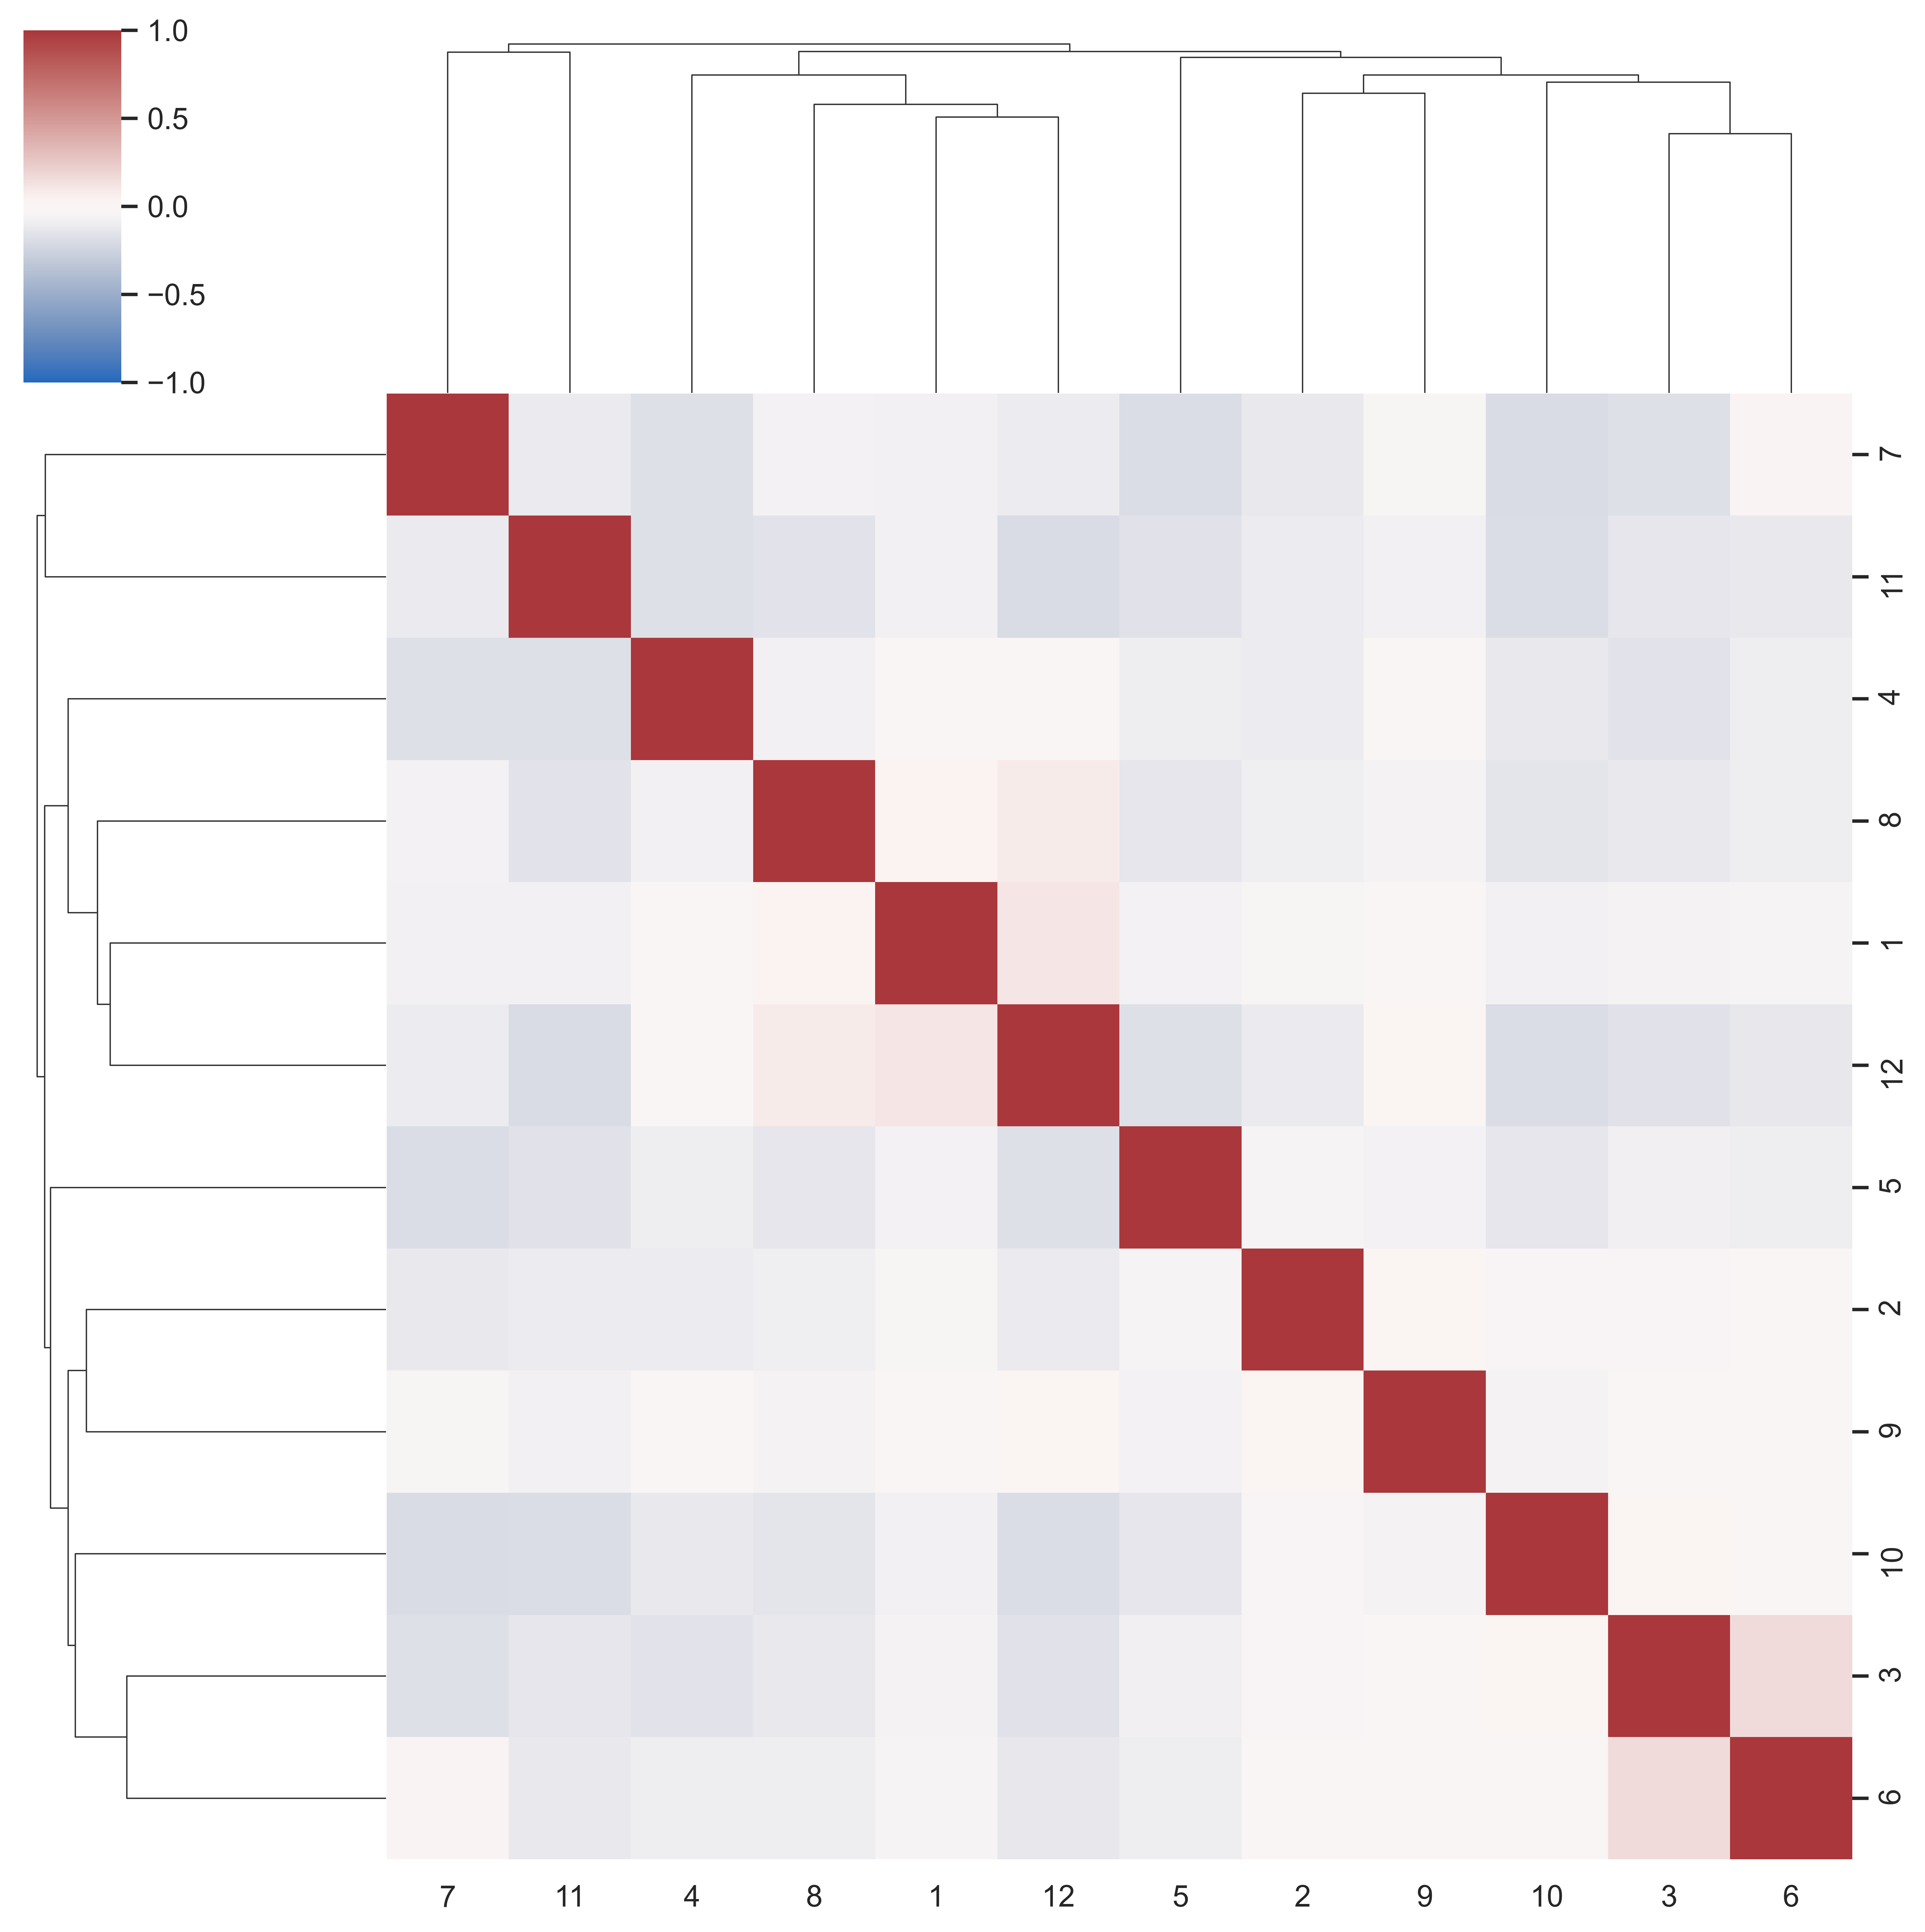

In [146]:
import scipy.cluster.hierarchy as sc

#Now check how the correlation compares, should get same results as above
# Calculate the correlation matrix
cov_matrix = beta_and_scale_df_a.corr()

# Create a custom clustermap with masked upper triangle
sns.set(style='white')
cg = sns.clustermap(cov_matrix, cmap='vlag', figsize=(10, 10), metric = "euclidean", vmin = -1, vmax = 1) 
# plt.close() #comment to visualize
# cg.savefig("../output_data/Basis_figures/Figure2ex/CorrMatrix.png", dpi = 600, bbox_inches='tight')
# cg.savefig("../output_data/Basis_figures/Figure2ex/CorrMatrix.pdf", dpi = 600, bbox_inches='tight')

# Extract the column linkage matrix
dendrogram = cg.dendrogram_row.linkage
reord_ind = np.arange(1, hyperparameters['n_basis']+1,1)


height_threshold = .5
clusters = sc.cut_tree(dendrogram, height=height_threshold).flatten()
basis_clust = []
for i in np.unique(clusters):
    basis_clust.append(reord_ind[clusters == i])
    print("Cluster {}: = {}".format(i, reord_ind[clusters == i]))

If correlation between basis are very close to 1 or you can visually see there are repeated basis run the code below.

In [147]:
#Get Basis
basis_a_comb = basis_a.copy()
beta_and_scale_df_a_comb = beta_and_scale_df_a.copy()
del_basis = np.empty(0, dtype = int) #Store indices of basis to delete

#Combine basis functions that are similar and sum the beta values and normalize the basis function
for clust in basis_clust:
    if len(clust) > 1:
        del_basis = np.append(del_basis, clust[1:])
        basis_a_comb[:,clust[0]-1] = np.sum(basis_a_comb[:,clust-1], axis = 1)/len(clust)
        beta_and_scale_df_a_comb[clust[0]] = beta_and_scale_df_a_comb[clust].sum(axis = 1)

print(del_basis-1)
beta_and_scale_df_a_comb = beta_and_scale_df_a_comb.drop(del_basis,axis = 1)
basis_a_comb = np.delete(basis_a_comb, del_basis-1, 1)
        
beta_and_scale_df_a_comb.columns = range(1,len(beta_and_scale_df_a_comb.columns)+1,1)



[]


## Displaying Results and Statistical Analysis

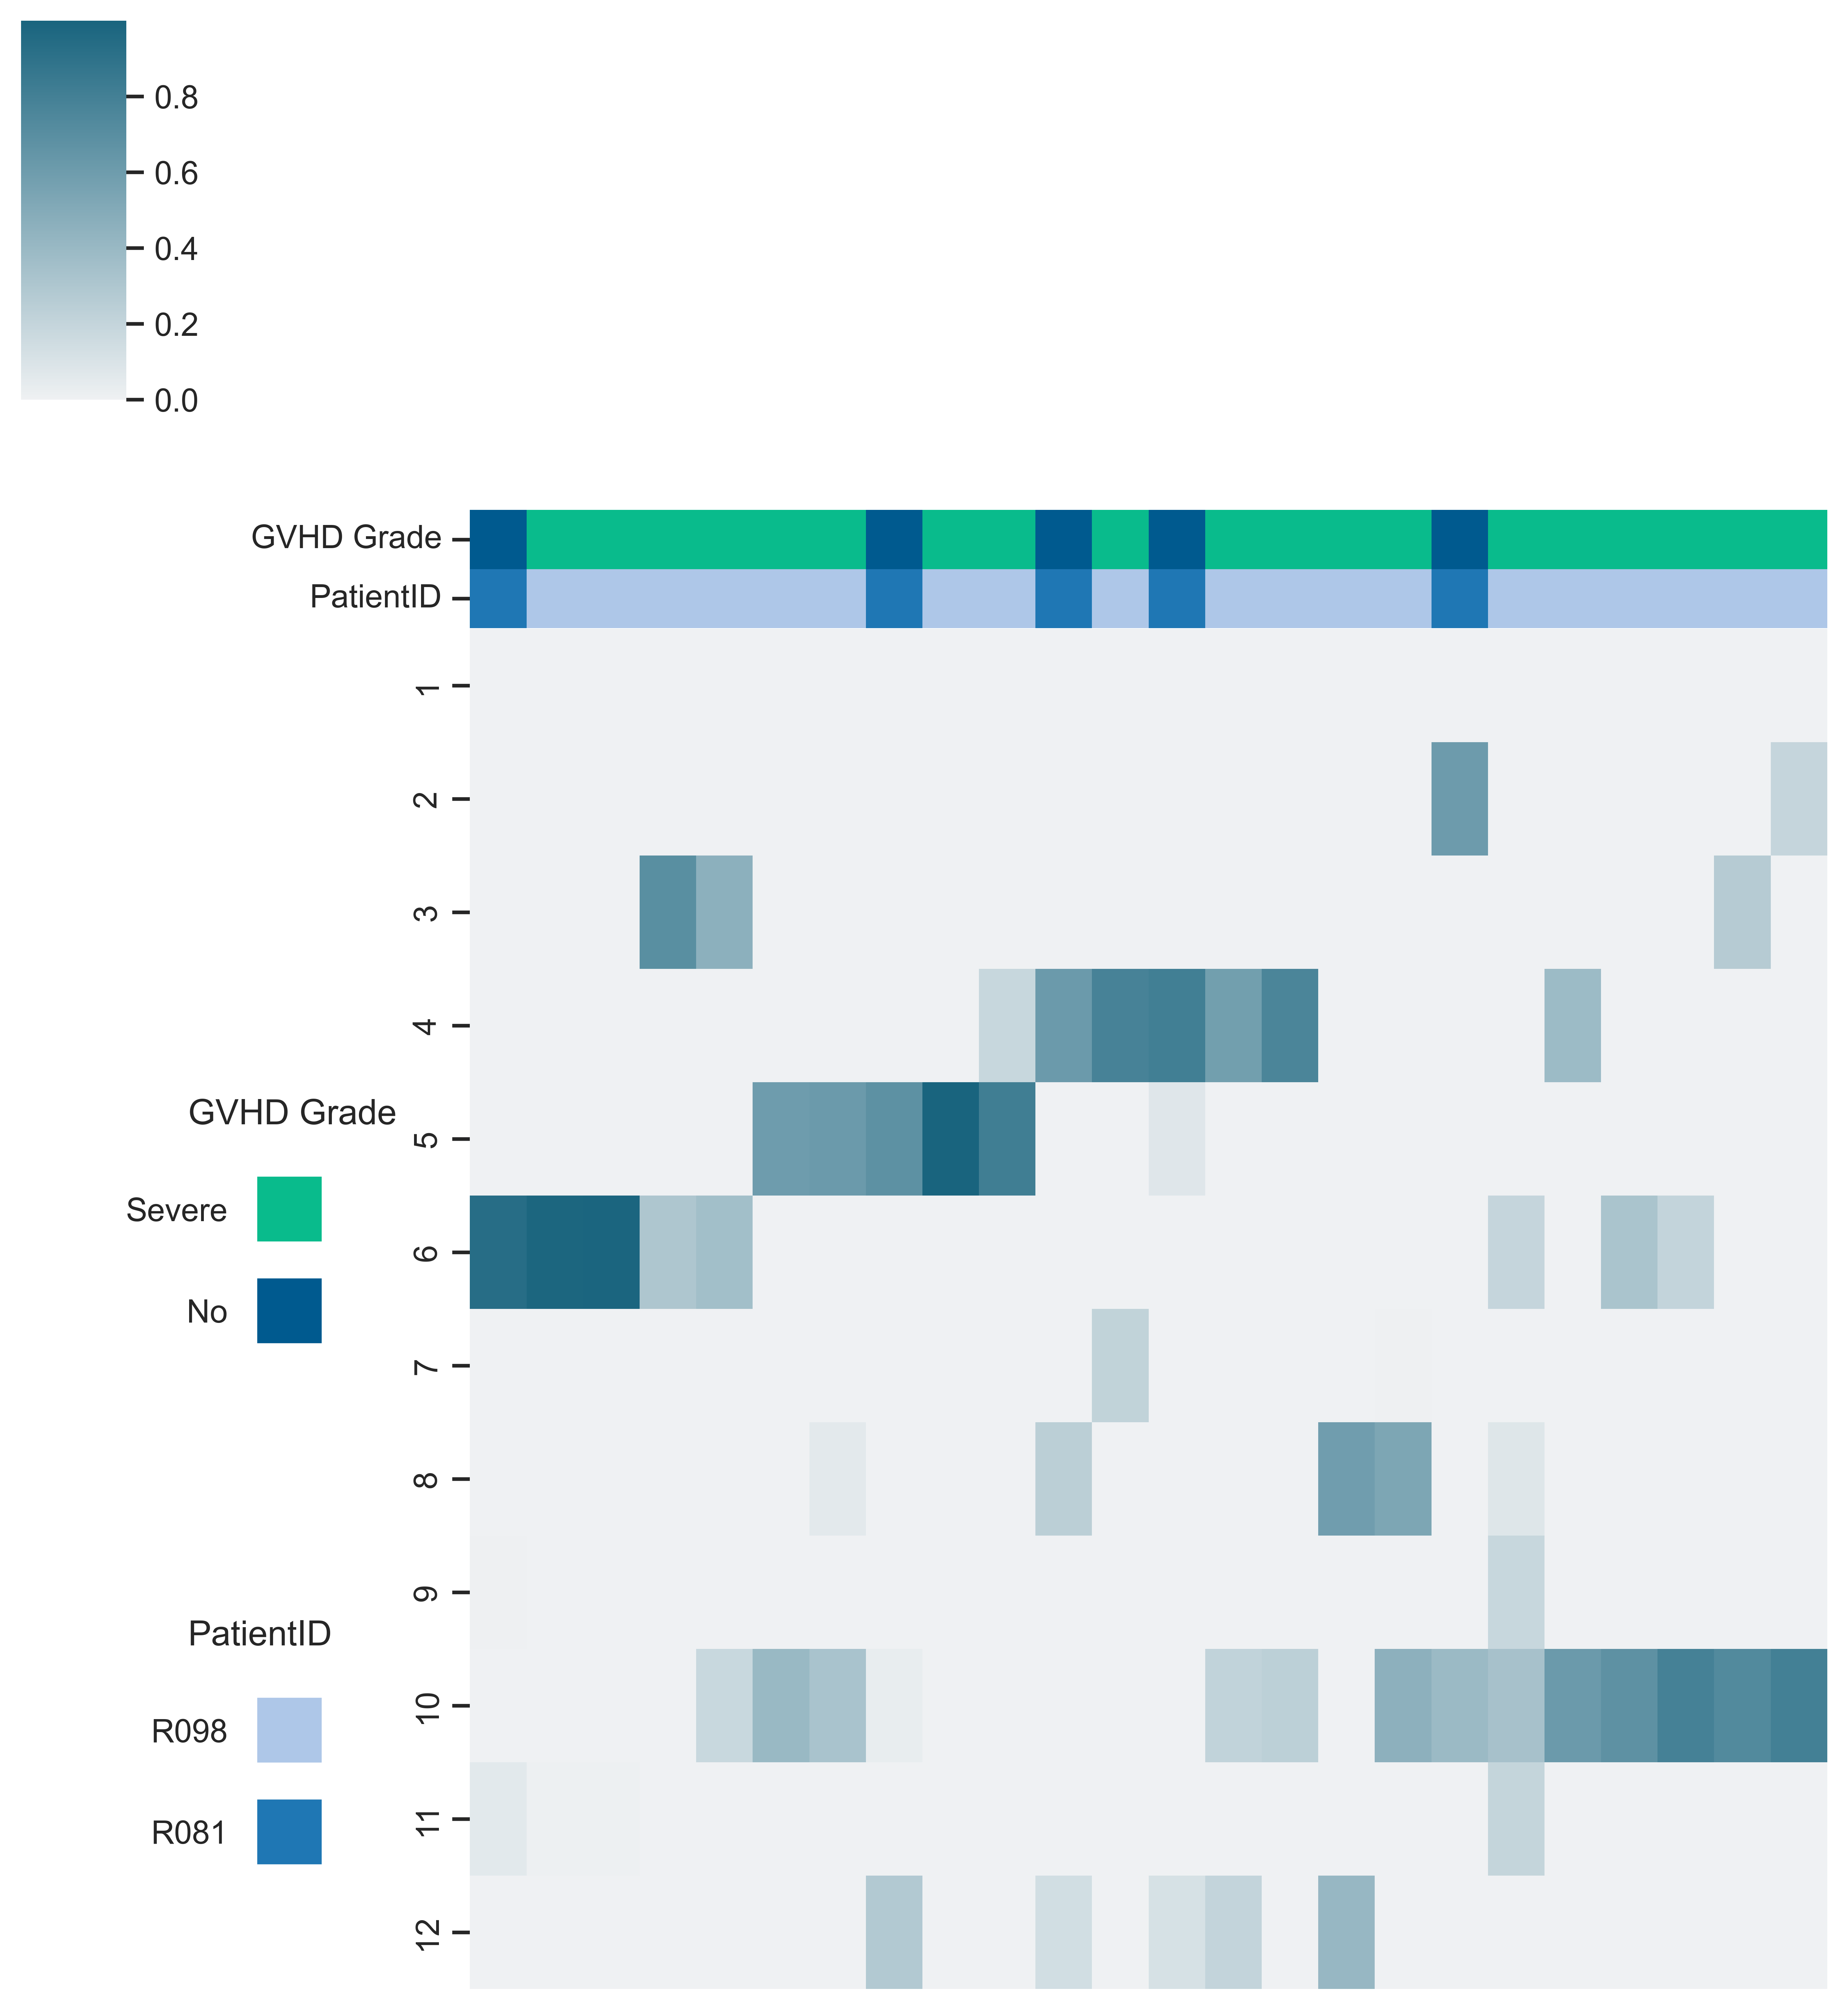

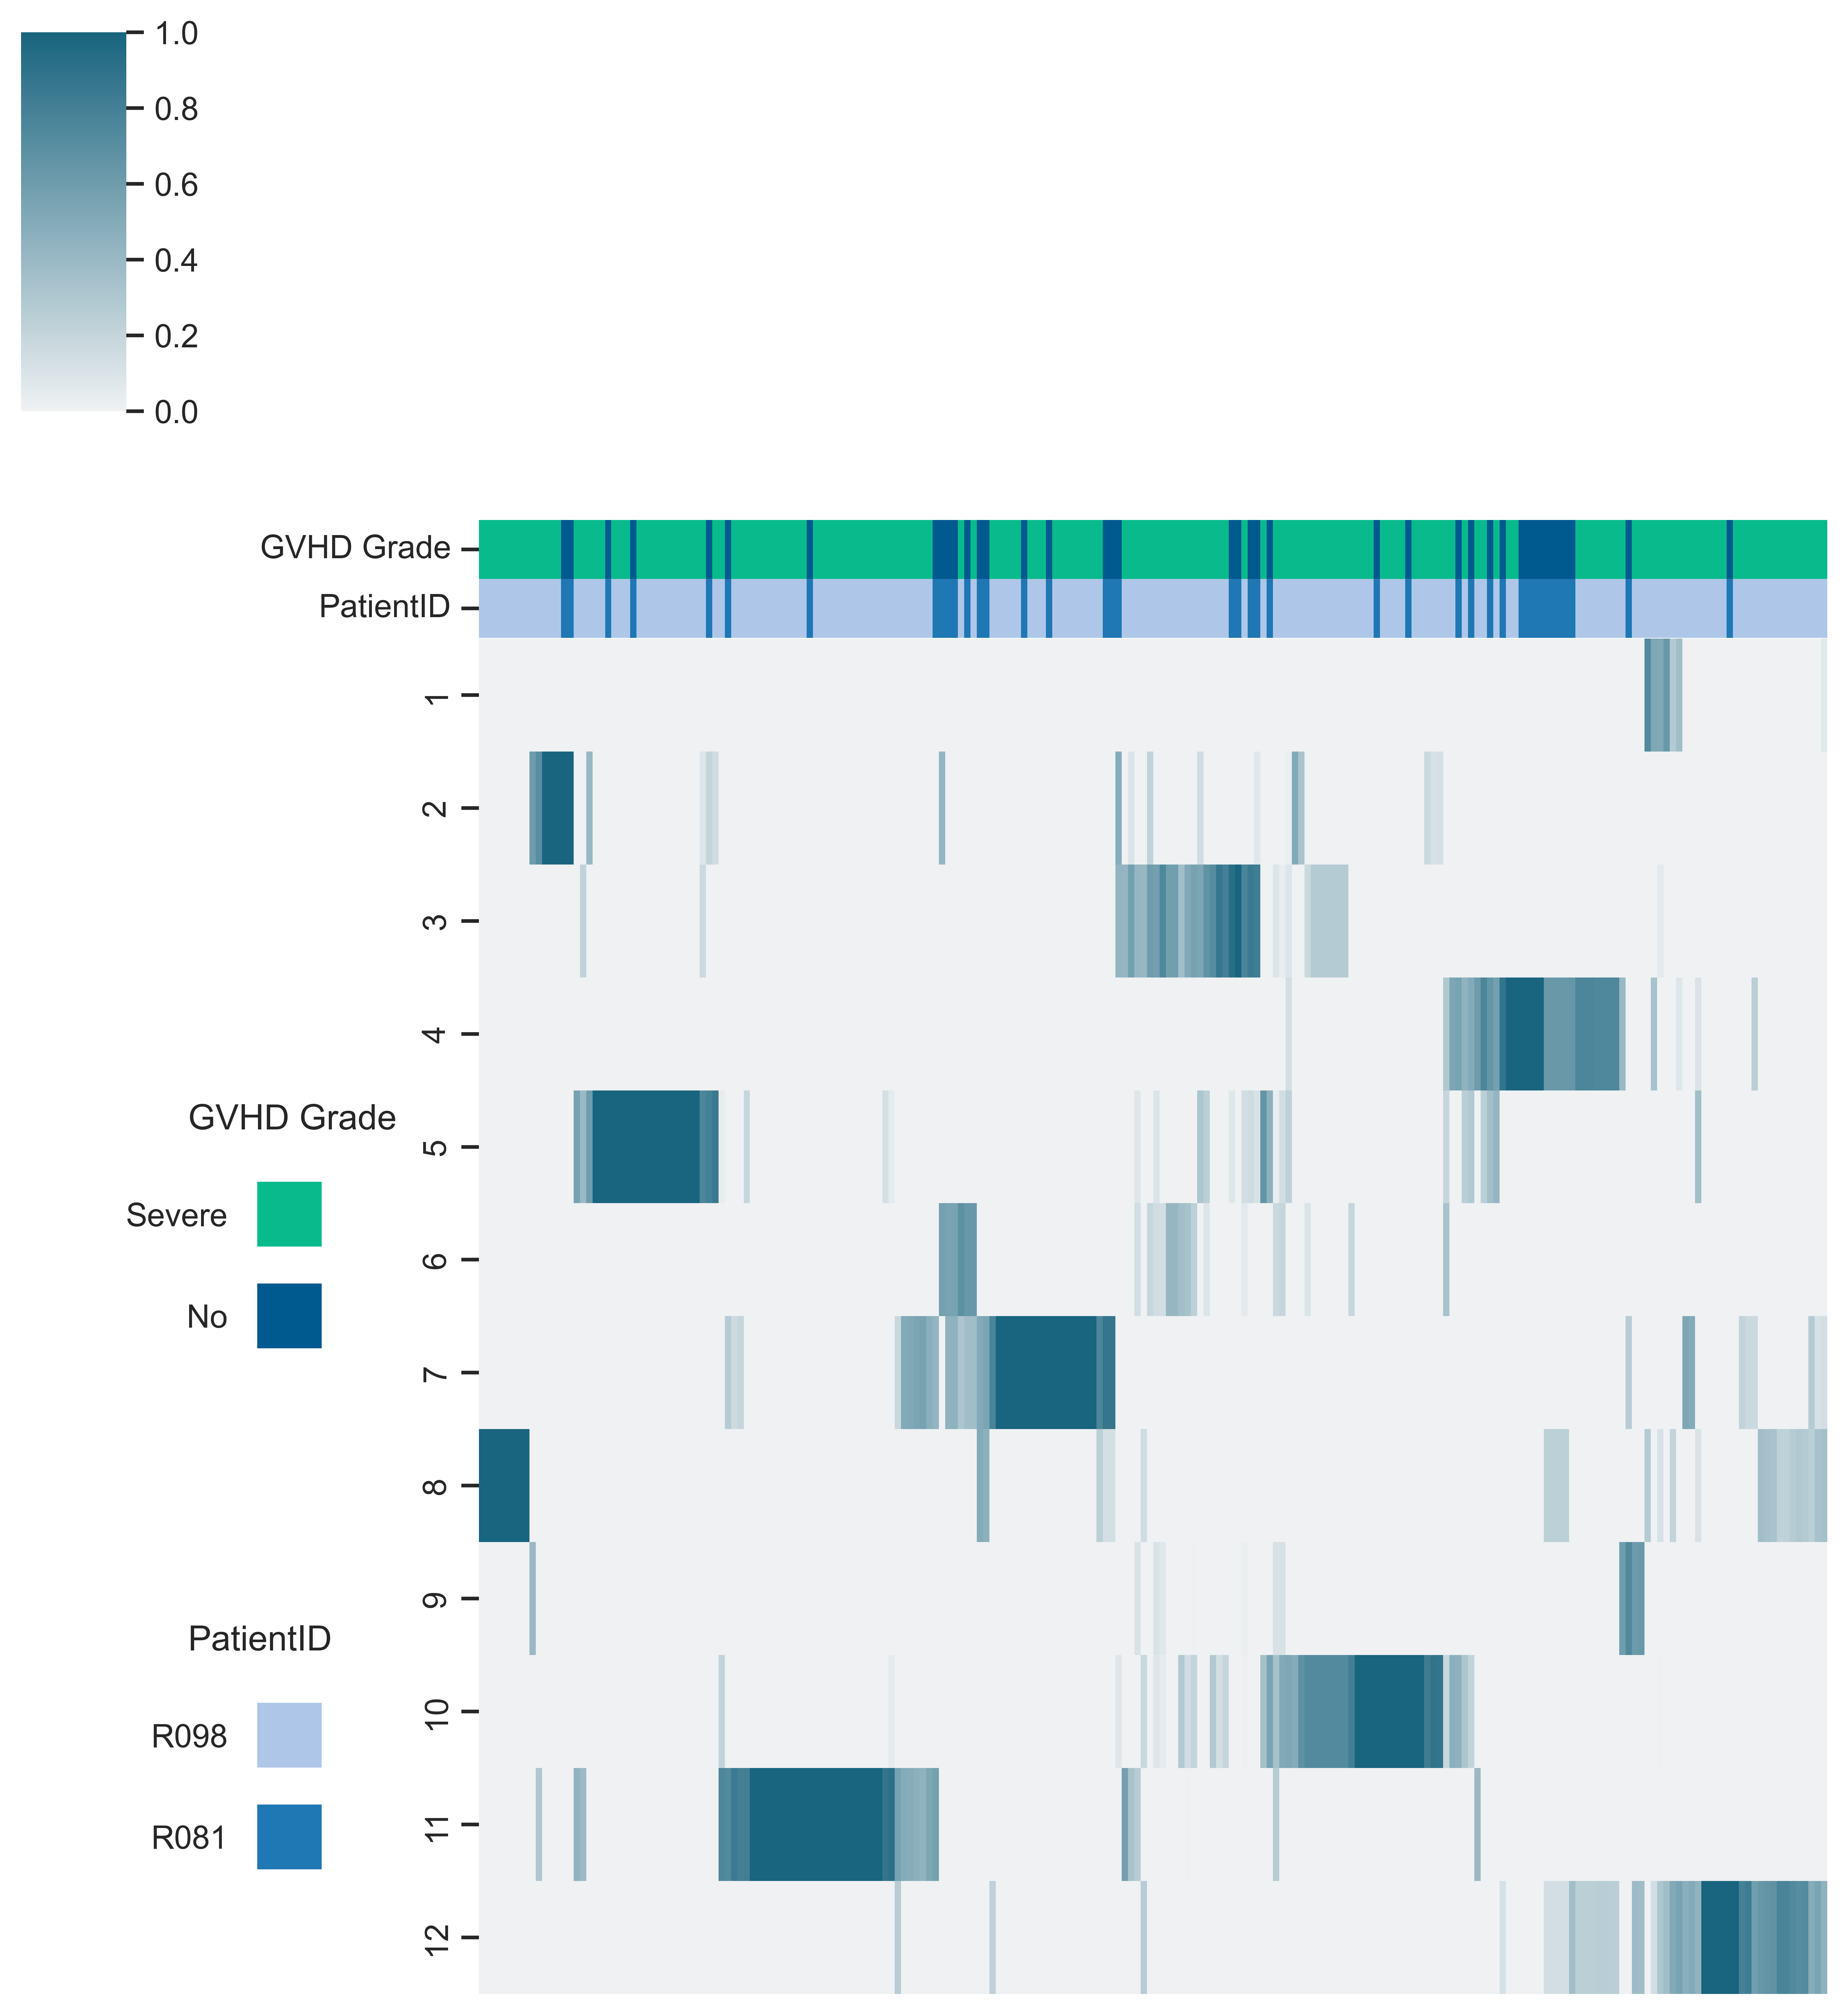

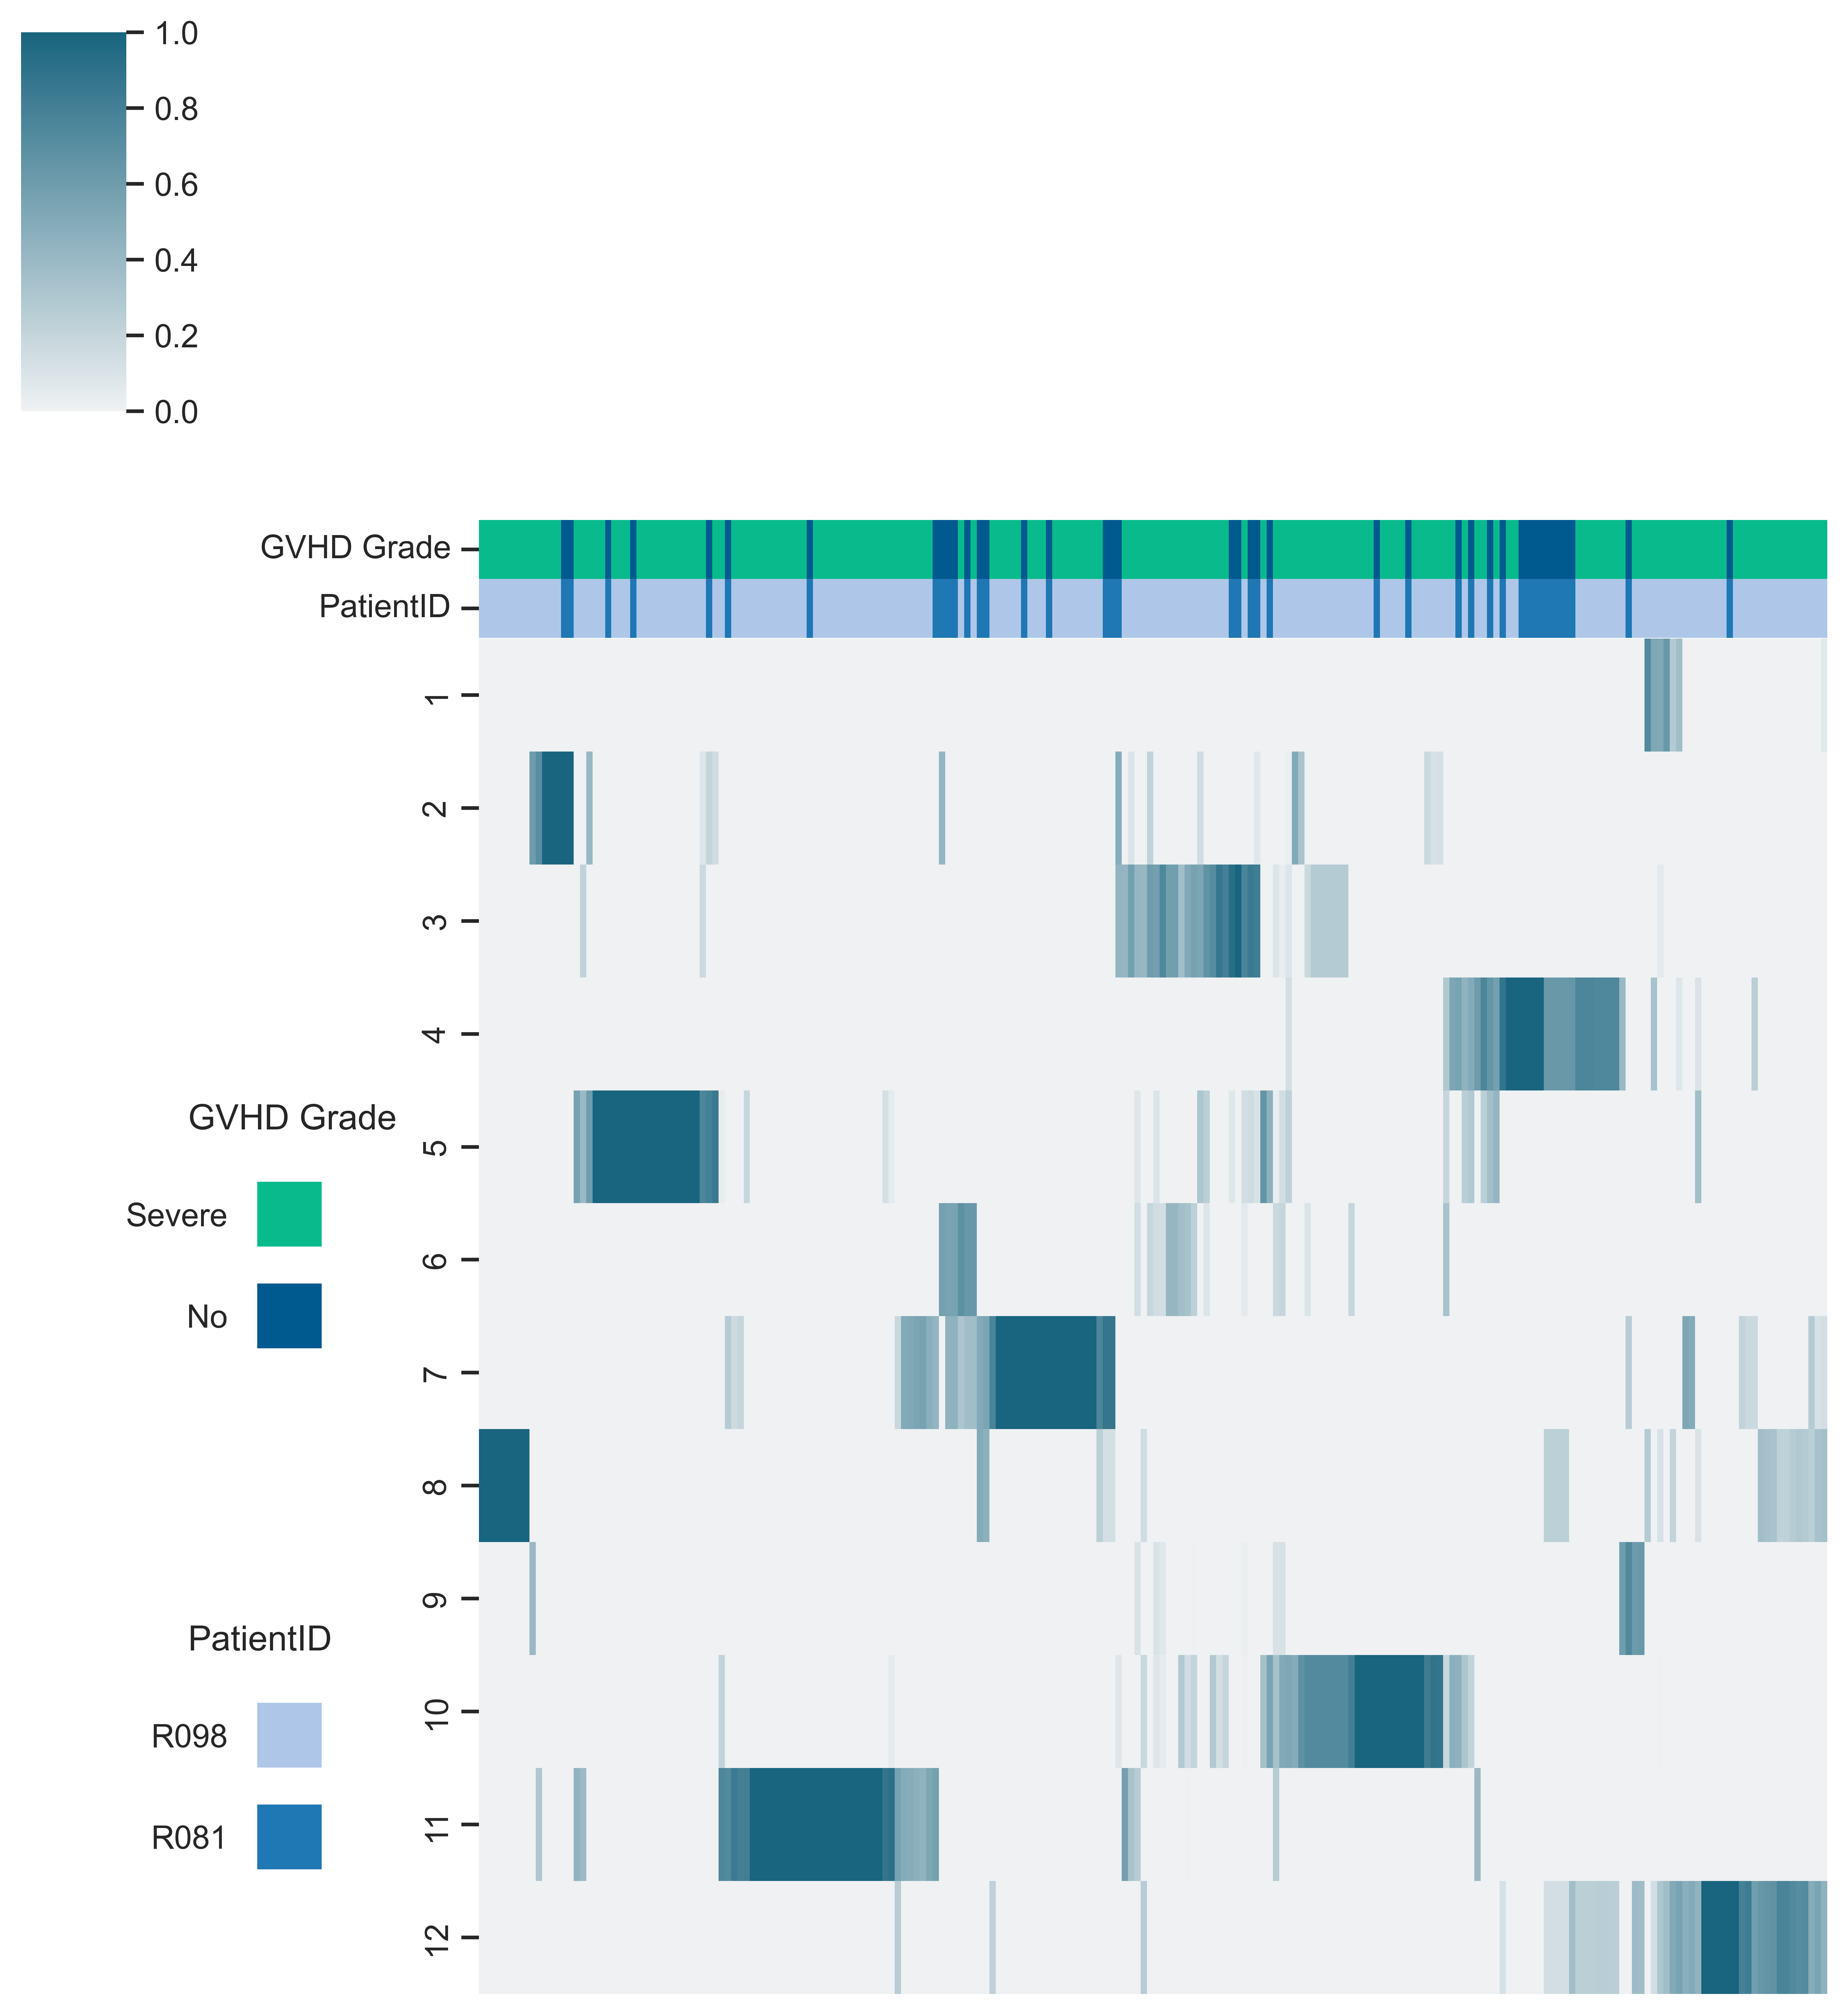

In [148]:
row_categories = ["GVHD Grade", "PatientID"]

data_filt_a_val["GVHD Grade"] = pd.Categorical(data_filt_a_val["GVHD_GRADE_1"].astype(str), ["No", "Mild", "Severe"], ordered = False)
data_filt_a_val["GVHD Grade"] = data_filt_a_val["GVHD_GRADE_1"]


data_filt_a_train["GVHD Grade"] = pd.Categorical(data_filt_a_train["GVHD_GRADE_1"].astype(str), ["No", "Mild", "Severe"], ordered = True)
data_filt_a_train["GVHD Grade"] = data_filt_a_train["GVHD_GRADE_1"]

legend_positions = np.array([                        
    [1,2, .75,.75],
    [1,0.35, .75,.75]
    ])

legend_colors = [
    sns.color_palette(["#005A8F", "#09BB8C" , "#B85000"]),
    sns.color_palette("tab20", len(np.unique(data_filt_a_train["PatientID"]))),
]

offset = [-1, -1, ]

legend_sizes = [
    (1,1.5),
    (1,1.5),
]

#Clustermap of Validation Data
clustermap(beta_and_scale_df_a_val,data_filt_a_val, row_categories, offset, legend_positions, legend_colors, legend_sizes, "GVHD")

#Clustermap of Training Data
clustermap(beta_and_scale_df_a, data_filt_a_train.drop("index", axis = 1), row_categories, offset, legend_positions, legend_colors, legend_sizes, "GVHD")


#Reorder the columns of beta_and_scale_df_a_comb to match the order of the clusters
beta_and_scale_df_a_comb_reord = beta_and_scale_df_a_comb#[[4,8,1,2,7,9,3,5,6,10]]

#Display reordered clustermap of combined data
ax = clustermap(beta_and_scale_df_a_comb_reord, data_filt_a_train.drop("index", axis = 1), row_categories, offset, legend_positions, legend_colors, legend_sizes, "GVHD")

#Uncomment below to save the clustermap
# ax.savefig("../output_data/Basis_figures/Figure2/BasisHeatmap.png", dpi = 600, bbox_inches='tight')
# ax.savefig("../output_data/Basis_figures/Figure2/BasisHeatmap.pdf", dpi = 600, bbox_inches='tight')

